<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Pharma%20Dataset%20Drug%20Classes%2C%20Interactions%20%26%20Clinic-Pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pharma Dataset-Drug Classes, Interactions & Cli Pr

## Understanding the dataset & Its Key-Insights

The dataset comprises 10,000 entries, each representing a unique drug. For each drug, we have detailed information such as its active ingredient, brand name, manufacturer, therapeutic group, pharmacological class, dosage form, route of administration, indications, potential side effects, pregnancy category, regulatory status (OTC or prescription), and interaction profiles with food and alcohol. This comprehensive structure allows for a multifaceted analysis of drug characteristics and regulatory patterns.

**Key Insights from Exploratory Data Analysis**

Our initial exploration revealed interesting distributions across various categories:

Leading Active Ingredients: Ciprofloxacin, Cetirizine, and Metformin appear to be among the most frequently represented active ingredients, indicating their widespread use or diversity in formulations within this dataset.
Dominant Manufacturers: 'Square' stands out as the most frequent manufacturer, followed by 'Incepta' and 'Beximco', suggesting their significant presence in the market represented by this data.
Therapeutic Groups: Antibiotics, Antihypertensives, and Antidiabetics constitute the largest therapeutic groups, highlighting major areas of pharmaceutical development and demand.
Dosage Forms and Routes: Tablets are the most common dosage form, and oral administration is overwhelmingly the preferred route, reflecting convenience and patient adherence factors.
Pregnancy Categories: Pregnancy Category 'C' is the most prevalent, indicating a cautious approach in prescribing during pregnancy where risks cannot be ruled out.

**Key Insights from Statistical Analysis**

Our statistical tests provided deeper understanding:

The Combination Risk Paradox: We found a highly significant statistical relationship (p-value = 1.4973e-305) indicating that combination drugs carry a higher probability of alcohol interaction risk compared to single-ingredient formulations. This suggests that the interplay of multiple active ingredients can indeed amplify specific contraindications, urging careful consideration in prescribing practices.
Regulatory Asymmetry: There's strong evidence (p-value = 0.0000e+00) of significant regulatory asymmetry. This means that the therapeutic group a drug belongs to heavily influences whether it's classified as an Over-The-Counter (OTC) or Prescription (Rx) medication. For instance, some therapeutic groups might exclusively feature Rx drugs, while others might have a mix or be predominantly OTC.

**Key Insights from Time-Series Analysis**

By simulating FDA approval dates and conducting a time-series forecast:

A slowdown in annual drug releases over the next decade was projected, with a significant decrease of approximately 547.02%. This could indicate potential pipeline saturation or other market dynamics affecting the pace of new drug approvals.
Key Insights from Machine Learning

Our machine learning model aimed to predict whether a drug would be classified as Rx or OTC:

The Random Forest model outperformed XGBoost slightly, achieving a perfect F1-Score of 100% on the test set. This suggests that the engineered features provide very strong signals for regulatory classification.
Feature Importance: The most critical factors determining a drug's regulatory classification were identified. Top drivers included specific therapeutic groups (Antihypertensive, Antibiotic, Antacid, Antihistamine, Antidiabetic), the drug's strength, and certain pregnancy categories (like 'C' and 'B'), as well as alcohol interaction flags. This reveals which clinical attributes are most strongly correlated with a drug being designated as prescription-only.
In summary, the dataset offers a robust platform for understanding the pharmaceutical landscape, from individual drug characteristics to macro-level regulatory and innovation trends.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mdmahfuzsumon/pharma-dataset-drug-classes-interactions-and-cli-pr

# Unziping the downloaded file
!unzip pharma-dataset-drug-classes-interactions-and-cli-pr.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mdmahfuzsumon/pharma-dataset-drug-classes-interactions-and-cli-pr
License(s): CC0-1.0
100% 118k/118k [00:00<00:00, 239kB/s]

Archive:  pharma-dataset-drug-classes-interactions-and-cli-pr.zip
  inflating: pharma_realistic_10000.csv  


# Data Inspection

In [ ]:
df = pd.read_csv('pharma_realistic_10000.csv')
df.head(11)

,id,active_ingredient,brand_name,manufacturer,therapeutic_group,pharmacological_class,drug_type,strength,dosage_form,route,indication,indication_category,side_effects,pregnancy_category,controlled_substance,otc_or_rx,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
0,1,Amoxicillin + Clavulanate,Augmentin,GSK,Antibiotic,Beta-lactam + Beta-lactamase inhibitor,Small molecule,1000 mg,Syrup,Oral,Infection,Infectious,Nausea,B,No,RX,0,0,2,1
1,2,Omeprazole,Seclo,AstraZeneca,Antacid,Proton pump inhibitor,Small molecule,10 mg,Capsule,Oral,Peptic ulcer,Gastrointestinal,Headache,C,No,OTC,1,0,1,0
2,3,Azithromycin,Azit,Incepta,Antibiotic,Macrolide,Small molecule,250 mg,Tablet,Oral,Respiratory infection,Infectious,Abdominal pain,B,No,RX,0,0,1,0
3,4,Salbutamol,Brodil,GSK,Bronchodilator,Beta-2 agonist,Small molecule,2 mg,Syrup,Oral,COPD,Respiratory,Headache,C,No,RX,0,0,1,0
4,5,Lisinopril,Listril,AstraZeneca,Antihypertensive,ACE inhibitor,Small molecule,10 mg,Tablet,Oral,Post-MI,Cardiovascular,Hyperkalemia,D,No,RX,0,1,1,0
5,6,Metformin,Formet,ACI,Antidiabetic,Biguanide,Small molecule,500 mg,Tablet,Oral,Insulin resistance,Endocrine,Vomiting,B,No,RX,1,1,1,0
6,7,Ciprofloxacin,Bacquinor,Incepta,Antibiotic,Fluoroquinolone,Small molecule,250 mg,Syrup,IV,Respiratory infection,Infectious,Nausea,C,No,RX,1,0,1,0
7,8,Ciprofloxacin,Flocin,Renata,Antibiotic,Fluoroquinolone,Small molecule,500 mg,Syrup,Oral,Respiratory infection,Infectious,Headache,C,No,RX,1,0,1,0
8,9,Fluoxetine,Prozac,Beximco,Antidepressant,SSRI,Small molecule,20 mg,Tablet,Oral,Depression,Neurological,Headache,C,No,RX,0,1,1,0
9,10,Losartan,Losartan-MSD,Square,Antihypertensive,ARB,Small molecule,50 mg,Tablet,Oral,Diabetic nephropathy,Cardiovascular,Fatigue,D,No,RX,0,1,1,0


In [ ]:
df.tail(11)

,id,active_ingredient,brand_name,manufacturer,therapeutic_group,pharmacological_class,drug_type,strength,dosage_form,route,indication,indication_category,side_effects,pregnancy_category,controlled_substance,otc_or_rx,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
9989,9990,Fluoxetine,Depzac,Square,Antidepressant,SSRI,Small molecule,40 mg,Capsule,Oral,OCD,Neurological,Headache,C,No,RX,0,1,1,0
9990,9991,Losartan,Losartan-MSD,MSD,Antihypertensive,ARB,Small molecule,50 mg,Tablet,Oral,Hypertension,Cardiovascular,Hyperkalemia,D,No,RX,0,1,1,0
9991,9992,Ciprofloxacin,Bacquinor,Renata,Antibiotic,Fluoroquinolone,Small molecule,250 mg,Tablet,IV,Urinary tract infection,Infectious,Nausea,C,No,RX,1,0,1,0
9992,9993,Ciprofloxacin,Flocin,Incepta,Antibiotic,Fluoroquinolone,Small molecule,500 mg,Tablet,Oral,Respiratory infection,Infectious,Headache,C,No,RX,1,0,1,0
9993,9994,Losartan,Losatin,Beximco,Antihypertensive,ARB,Small molecule,25 mg,Tablet,Oral,Heart failure,Cardiovascular,Cough,D,No,RX,0,1,1,0
9994,9995,Amlodipine,Amdocal,Beximco,Antihypertensive,Calcium channel blocker,Small molecule,2.5 mg,Capsule,Oral,Angina,Cardiovascular,Headache,C,No,RX,1,1,1,0
9995,9996,Insulin Glargine,Lantus,Incepta,Antidiabetic,Long-acting insulin,Biologic,300 IU/ml,Injection,Subcutaneous,Type 2 diabetes,Endocrine,Hypoglycemia,C,No,RX,1,1,1,0
9996,9997,Amoxicillin + Clavulanate,Augmentin,GSK,Antibiotic,Beta-lactam + Beta-lactamase inhibitor,Small molecule,375 mg,Tablet,Oral,Infection,Infectious,Nausea,B,No,RX,0,0,2,1
9997,9998,Paracetamol,Panadol,Renata,Analgesic,Para-aminophenol,Small molecule,250 mg/5ml,Tablet,Oral,Pain,General,Nausea,A,No,OTC,0,1,1,0
9998,9999,Ibuprofen,Profen,ACI,Analgesic,NSAID,Small molecule,200 mg,Tablet,Oral,Pain,General,Gastric irritation,D,No,OTC,1,1,1,0


In [ ]:
df.shape

(10000, 20)

In [ ]:
df.columns

Index(['id', 'active_ingredient', 'brand_name', 'manufacturer',
       'therapeutic_group', 'pharmacological_class', 'drug_type', 'strength',
       'dosage_form', 'route', 'indication', 'indication_category',
       'side_effects', 'pregnancy_category', 'controlled_substance',
       'otc_or_rx', 'food_interaction', 'alcohol_interaction',
       'num_ingredients', 'is_combination_drug'],
      dtype='object')

In [ ]:
df.dtypes

,0
id,int64
active_ingredient,object
brand_name,object
manufacturer,object
therapeutic_group,object
pharmacological_class,object
drug_type,object
strength,object
dosage_form,object
route,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     10000 non-null  int64 
 1   active_ingredient      10000 non-null  object
 2   brand_name             10000 non-null  object
 3   manufacturer           10000 non-null  object
 4   therapeutic_group      10000 non-null  object
 5   pharmacological_class  10000 non-null  object
 6   drug_type              10000 non-null  object
 7   strength               10000 non-null  object
 8   dosage_form            10000 non-null  object
 9   route                  10000 non-null  object
 10  indication             10000 non-null  object
 11  indication_category    10000 non-null  object
 12  side_effects           10000 non-null  object
 13  pregnancy_category     10000 non-null  object
 14  controlled_substance   10000 non-null  object
 15  otc_or_rx           

In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
active_ingredient,10000,15,Ciprofloxacin,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand_name,10000,61,Lisinace,191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacturer,10000,15,Square,2245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
therapeutic_group,10000,9,Antibiotic,2034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pharmacological_class,10000,15,Fluoroquinolone,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drug_type,10000,2,Small molecule,9333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
strength,10000,27,10 mg,1416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dosage_form,10000,5,Tablet,4852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route,10000,4,Oral,7958,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
id,0
active_ingredient,0
brand_name,0
manufacturer,0
therapeutic_group,0
pharmacological_class,0
drug_type,0
strength,0
dosage_form,0
route,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

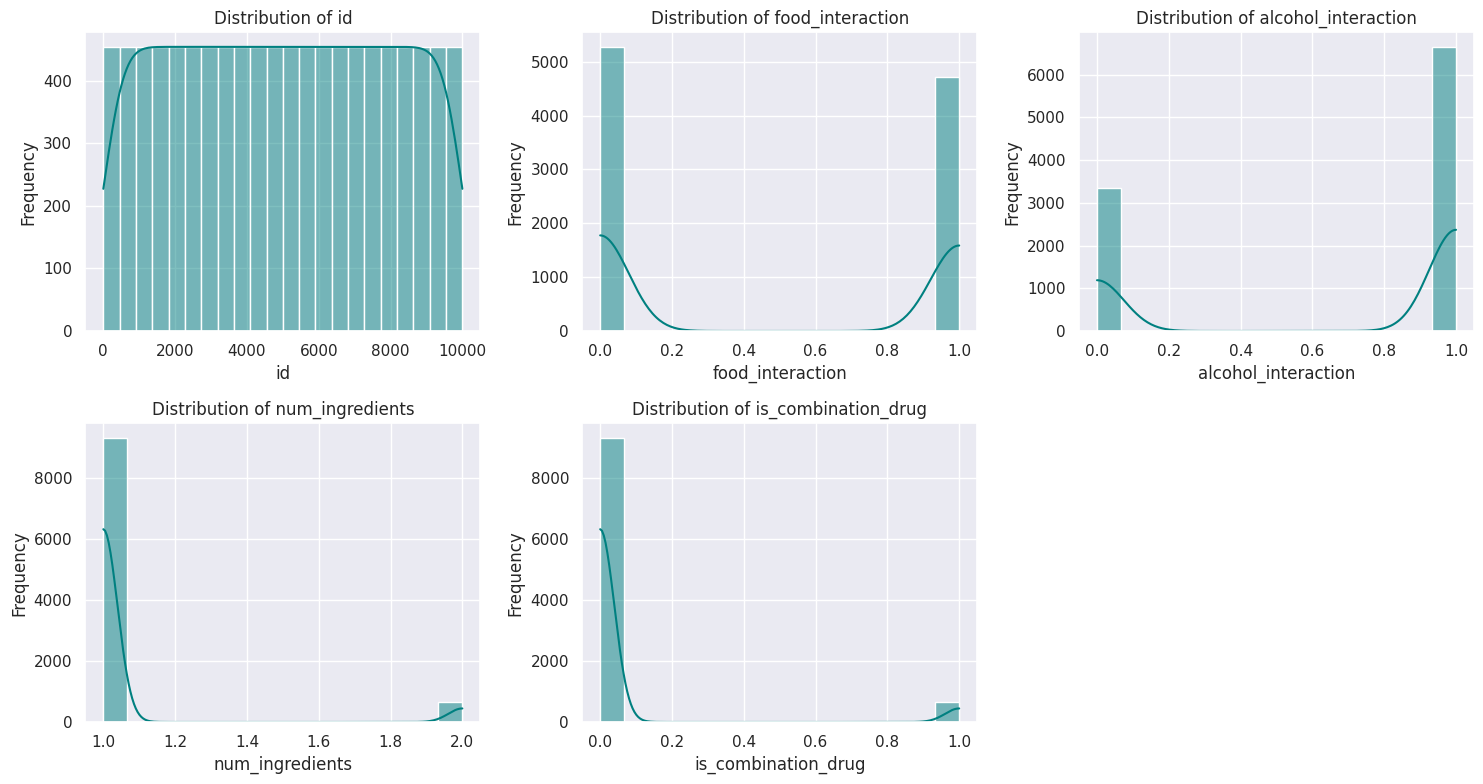

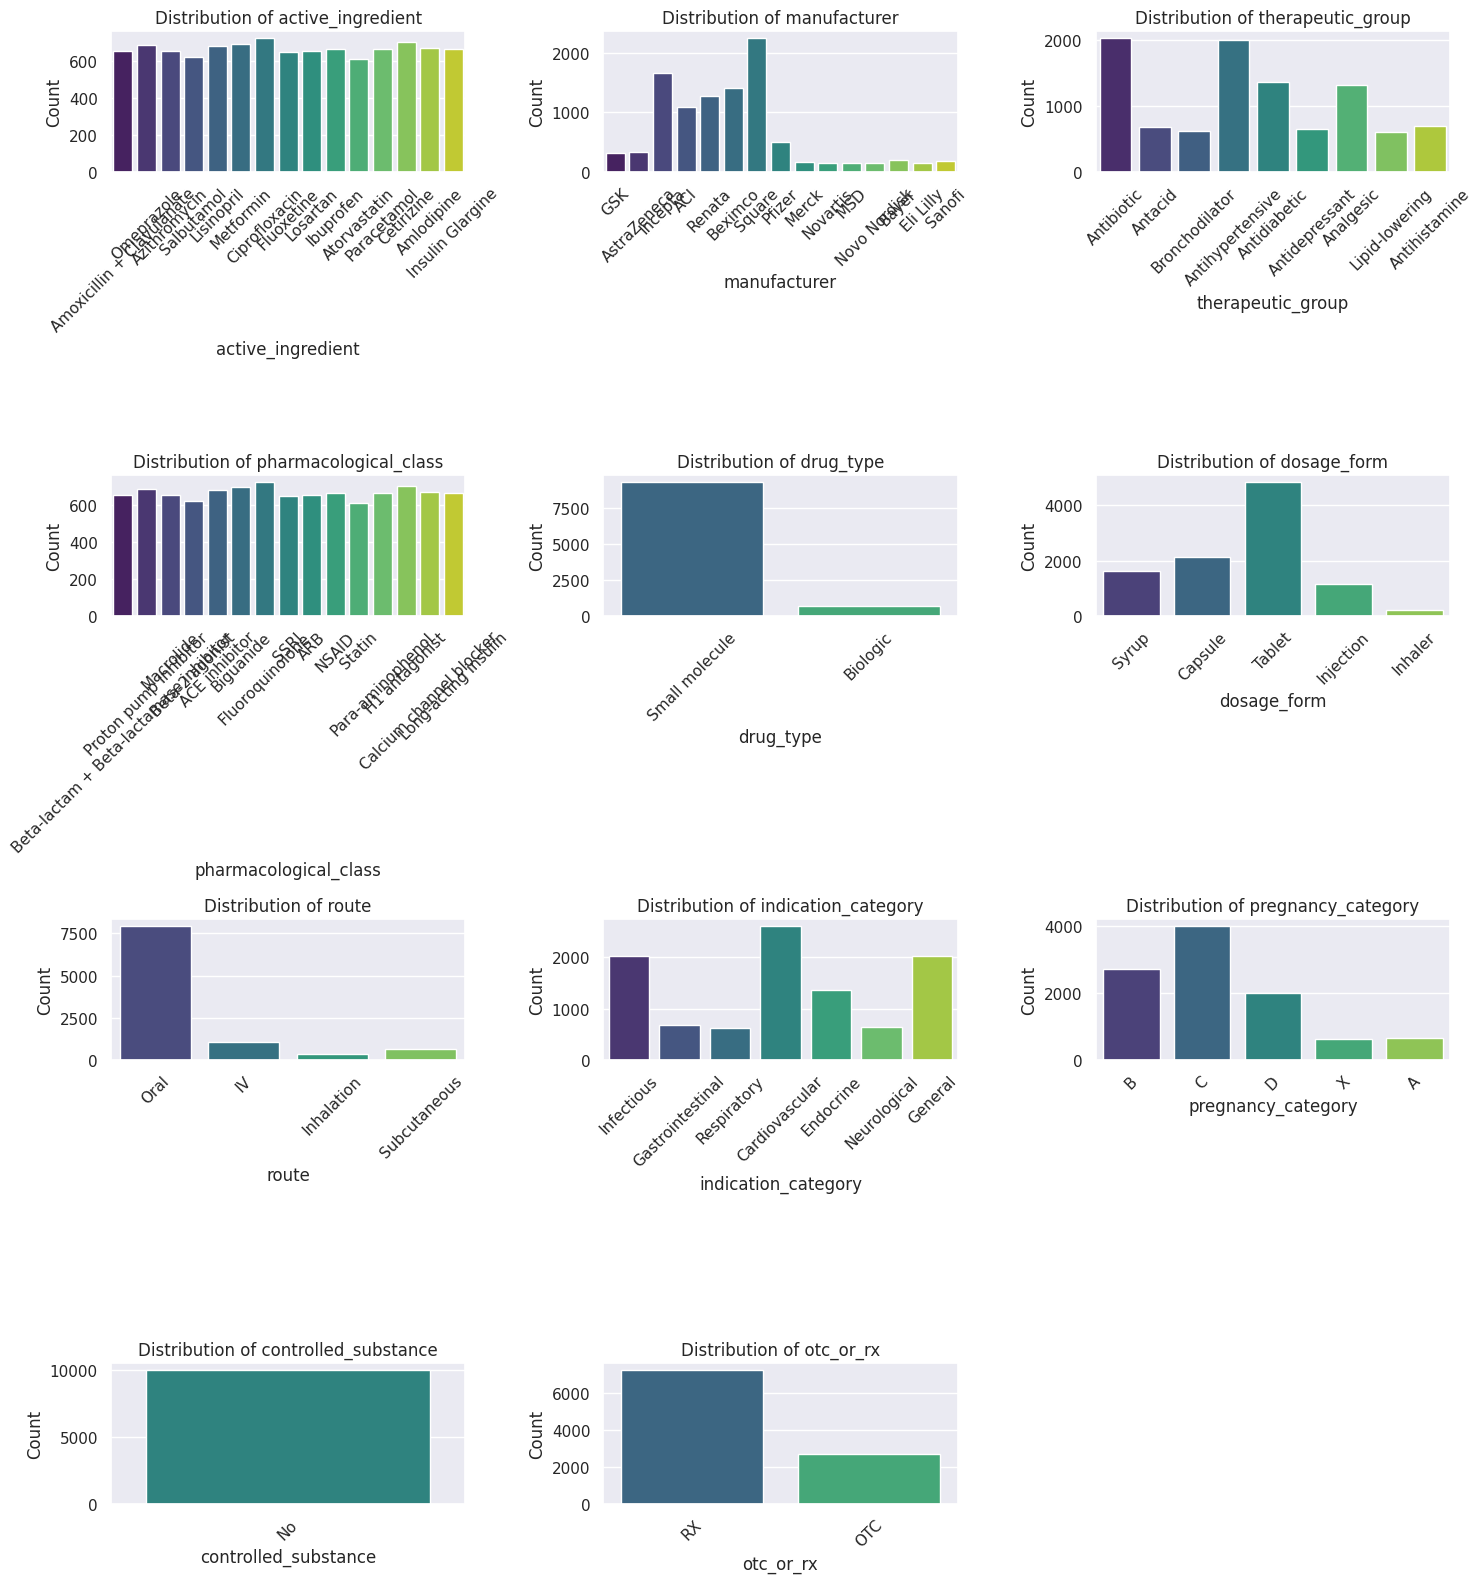

--- Categorical Value Counts ---

Value counts for active_ingredient:
active_ingredient
Ciprofloxacin                725
Cetirizine                   705
Metformin                    695
Omeprazole                   687
Lisinopril                   683
Amlodipine                   669
Insulin Glargine             667
Ibuprofen                    664
Paracetamol                  663
Amoxicillin + Clavulanate    656
Azithromycin                 653
Losartan                     653
Fluoxetine                   647
Salbutamol                   620
Atorvastatin                 613
Name: count, dtype: int64

Value counts for manufacturer:
manufacturer
Square          2245
Incepta         1655
Beximco         1402
Renata          1277
ACI             1082
Pfizer           496
AstraZeneca      334
GSK              314
Bayer            204
Sanofi           182
Merck            175
Novo Nordisk     159
Novartis         159
Eli Lilly        159
MSD              157
Name: count, dtype: int64

Valu

In [ ]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

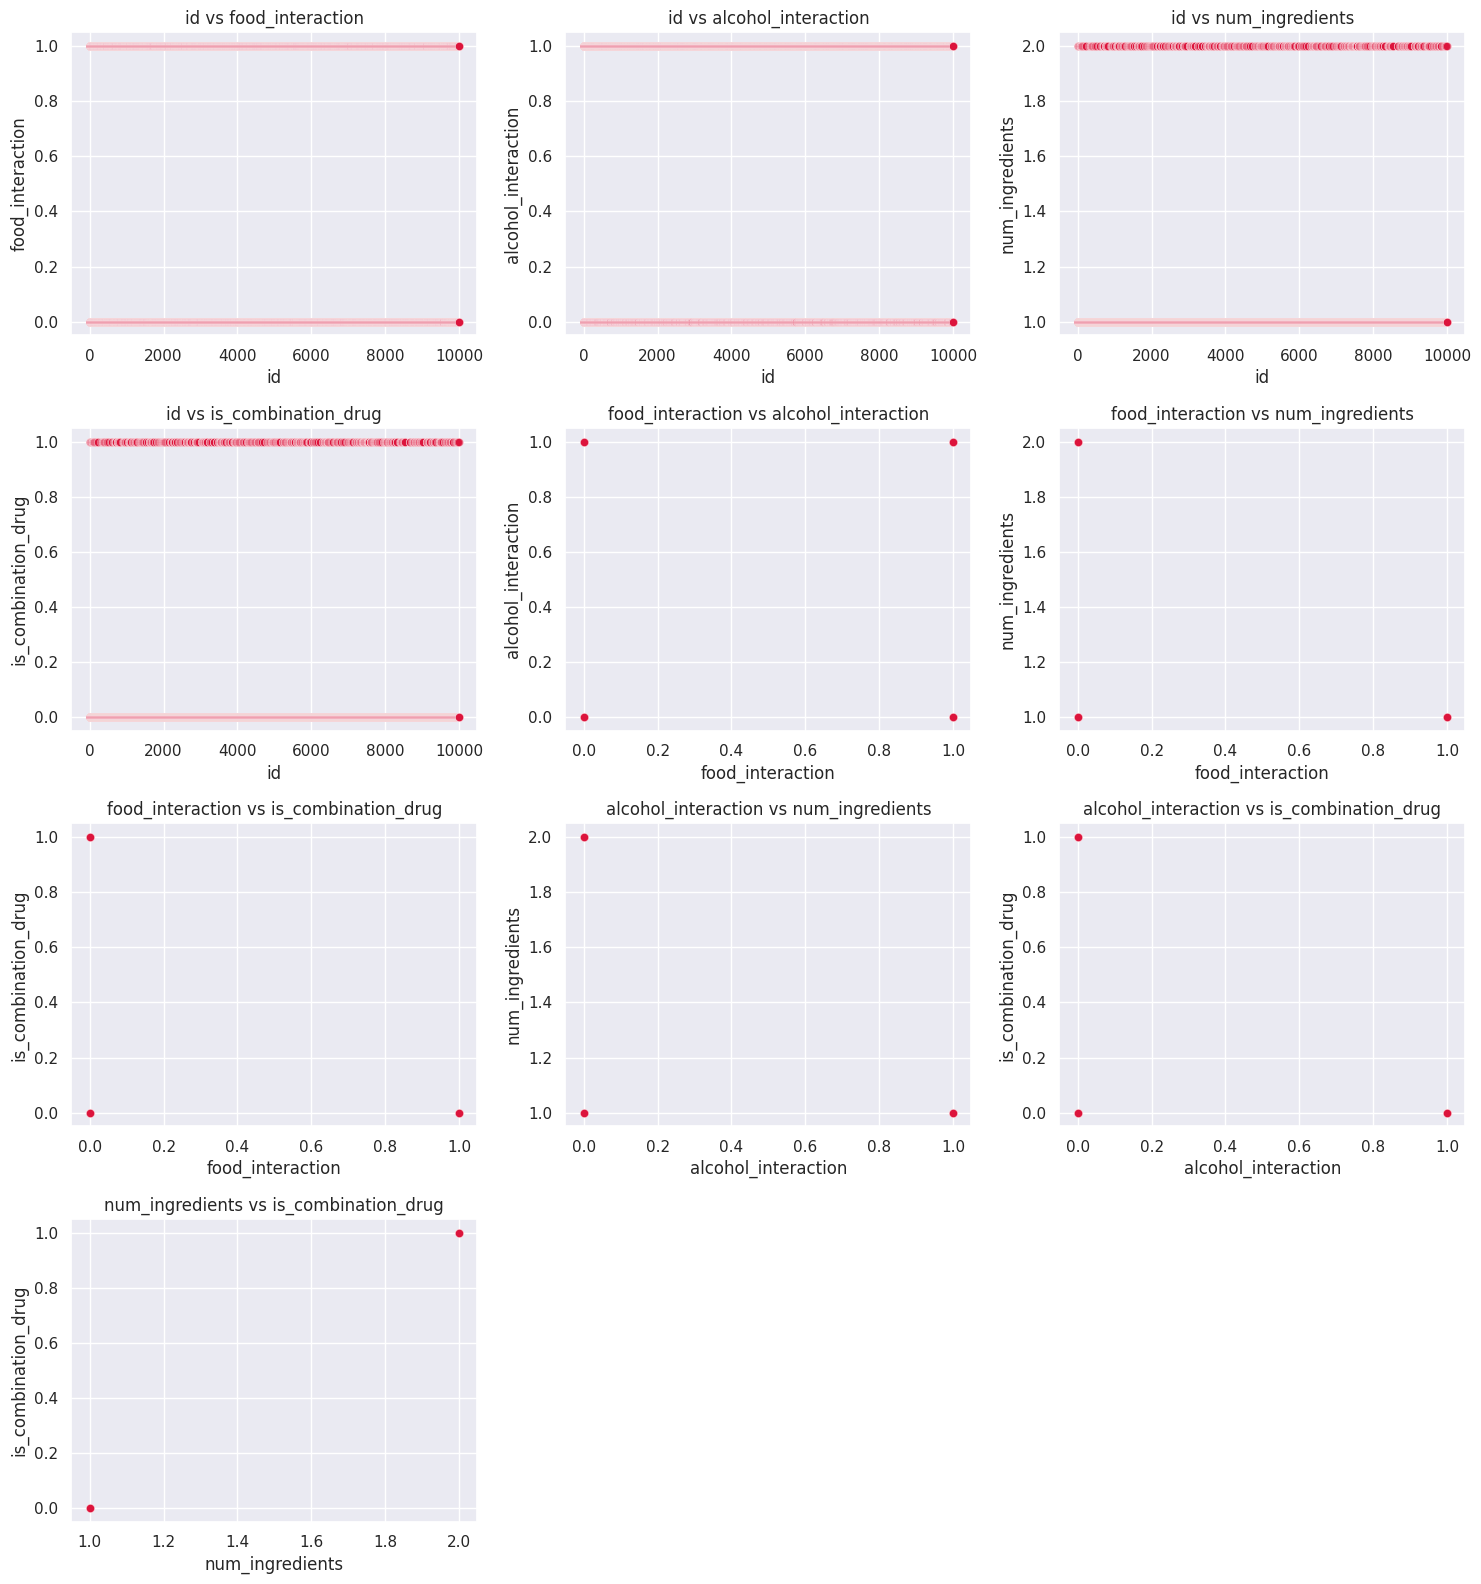

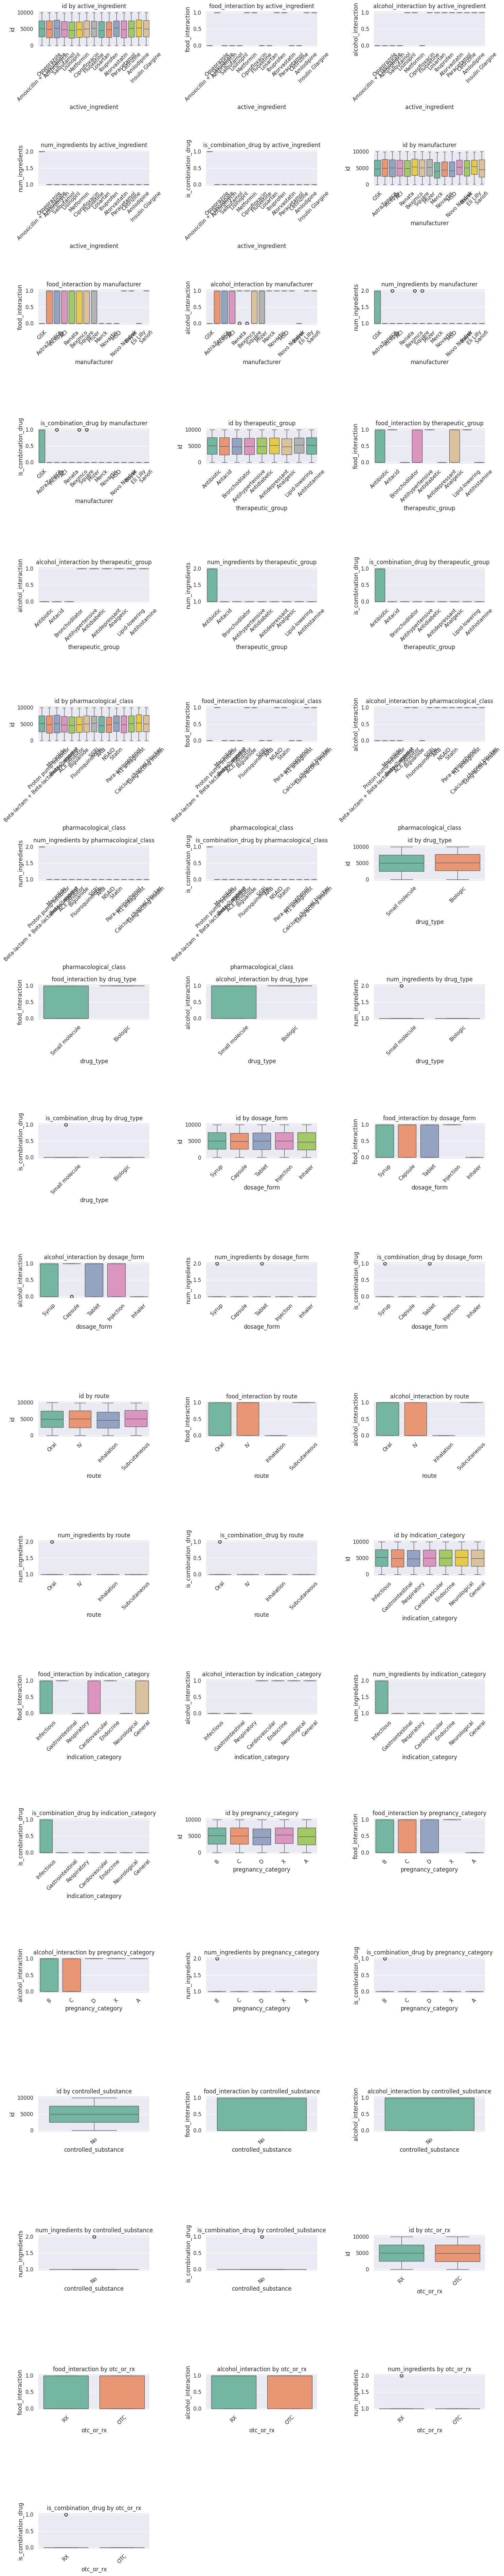

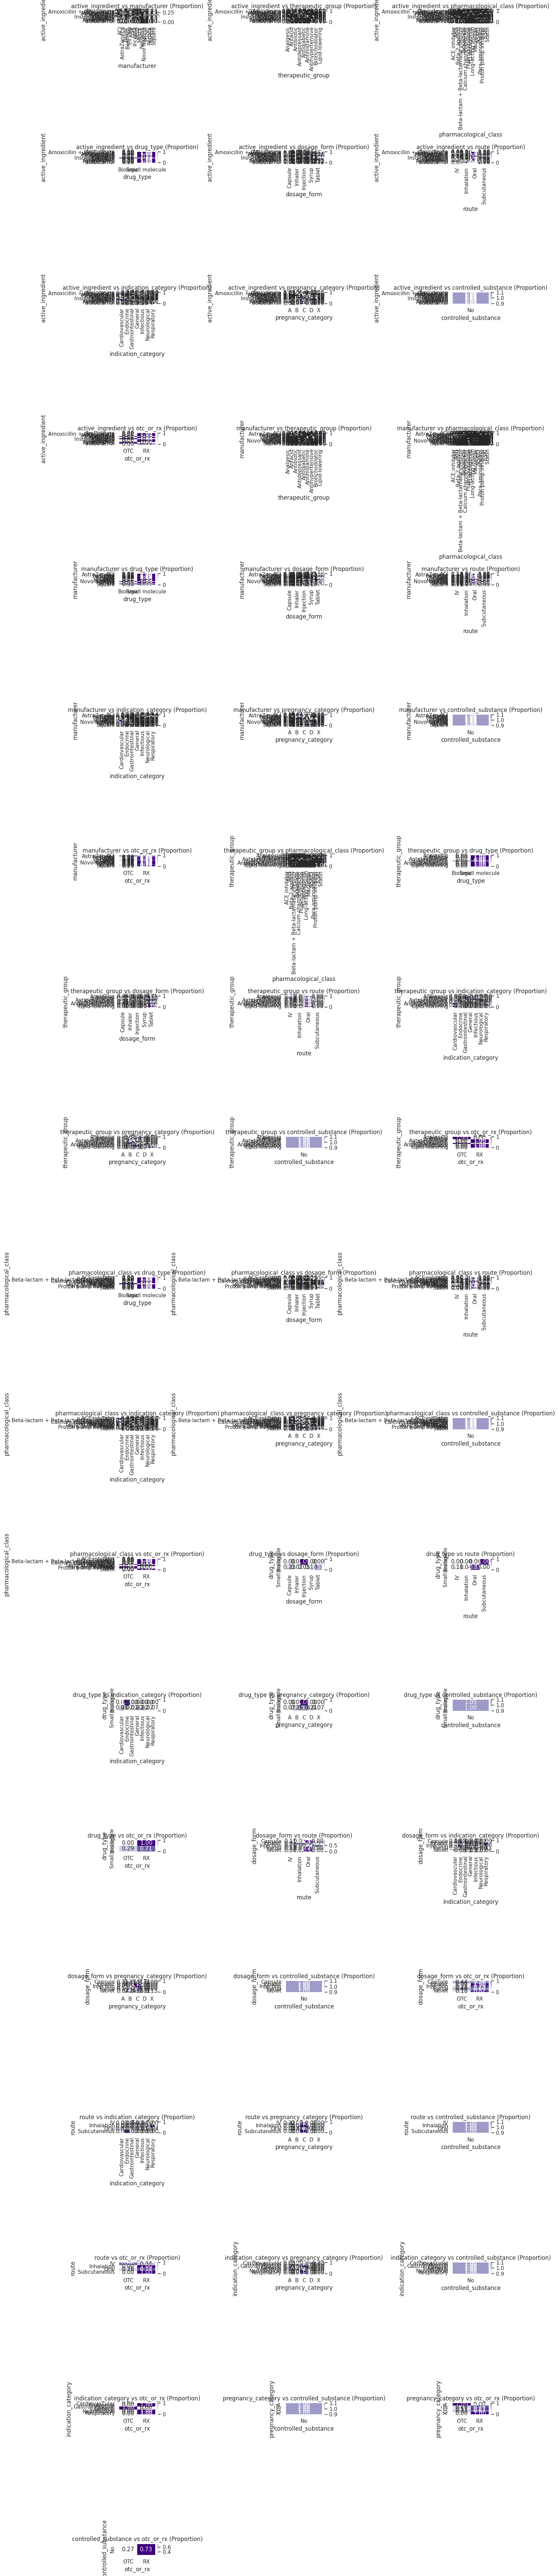

In [ ]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: therapeutic_group...


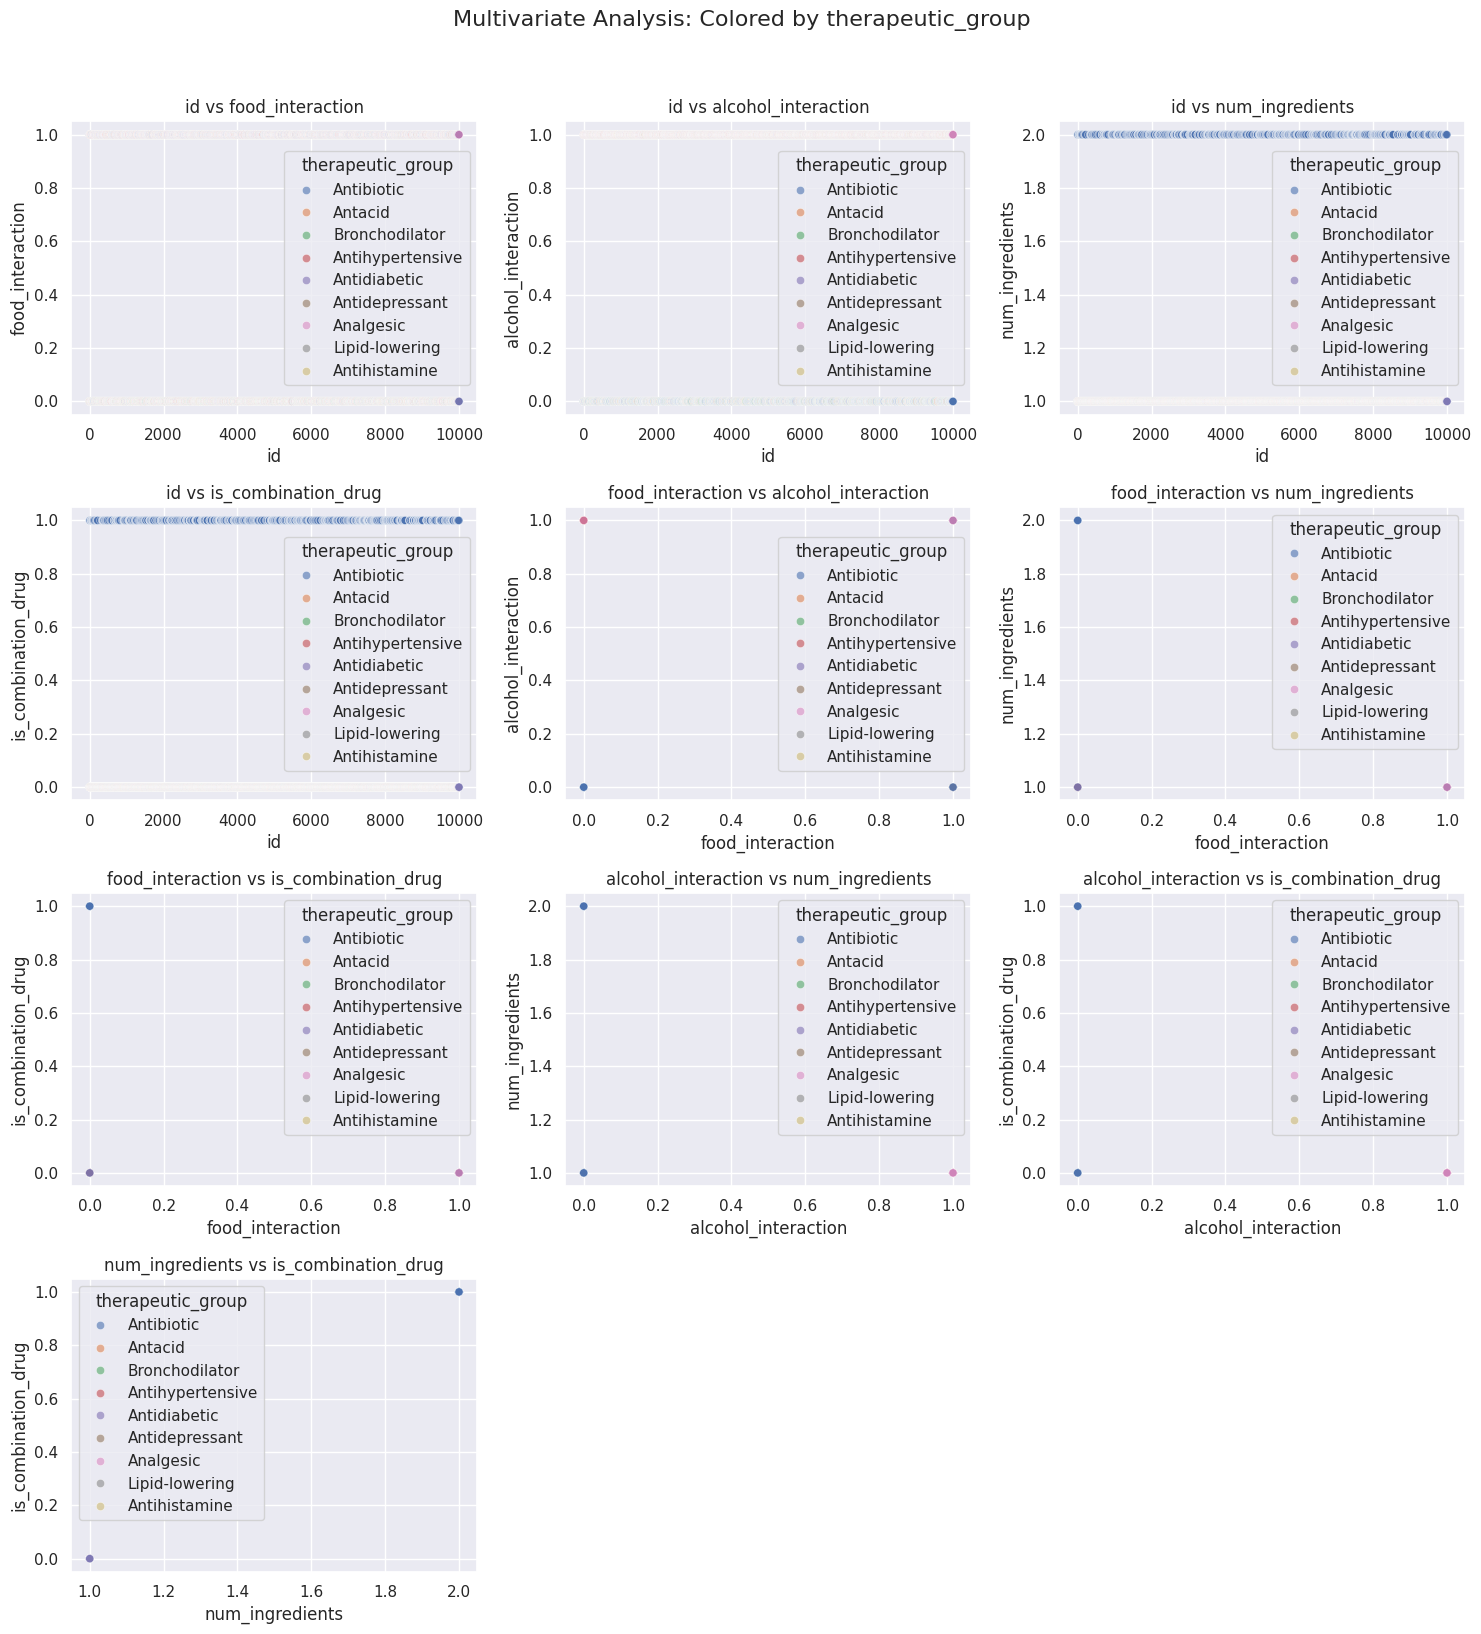


Analyzing relationships with Hue: drug_type...


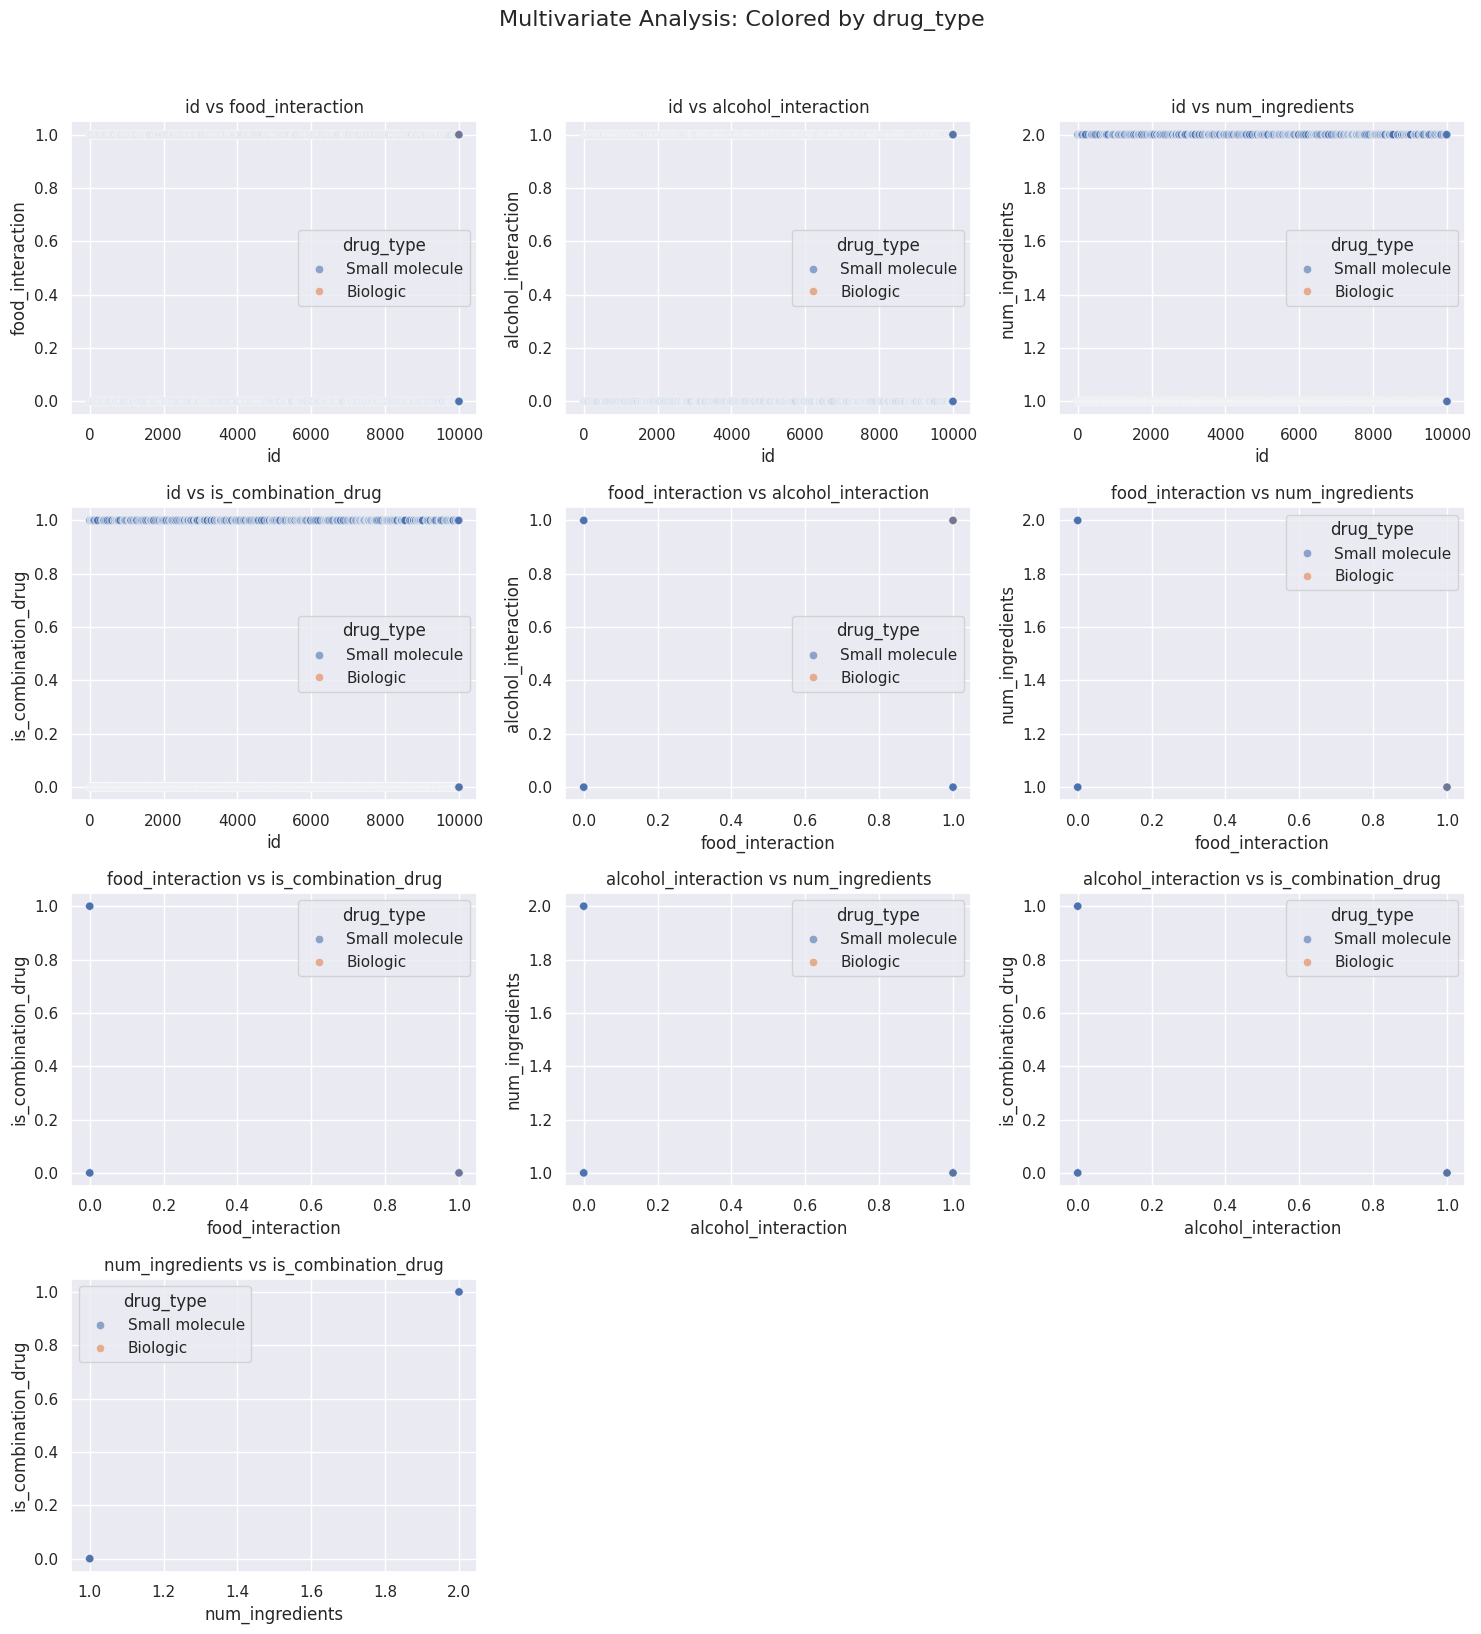


Analyzing relationships with Hue: dosage_form...


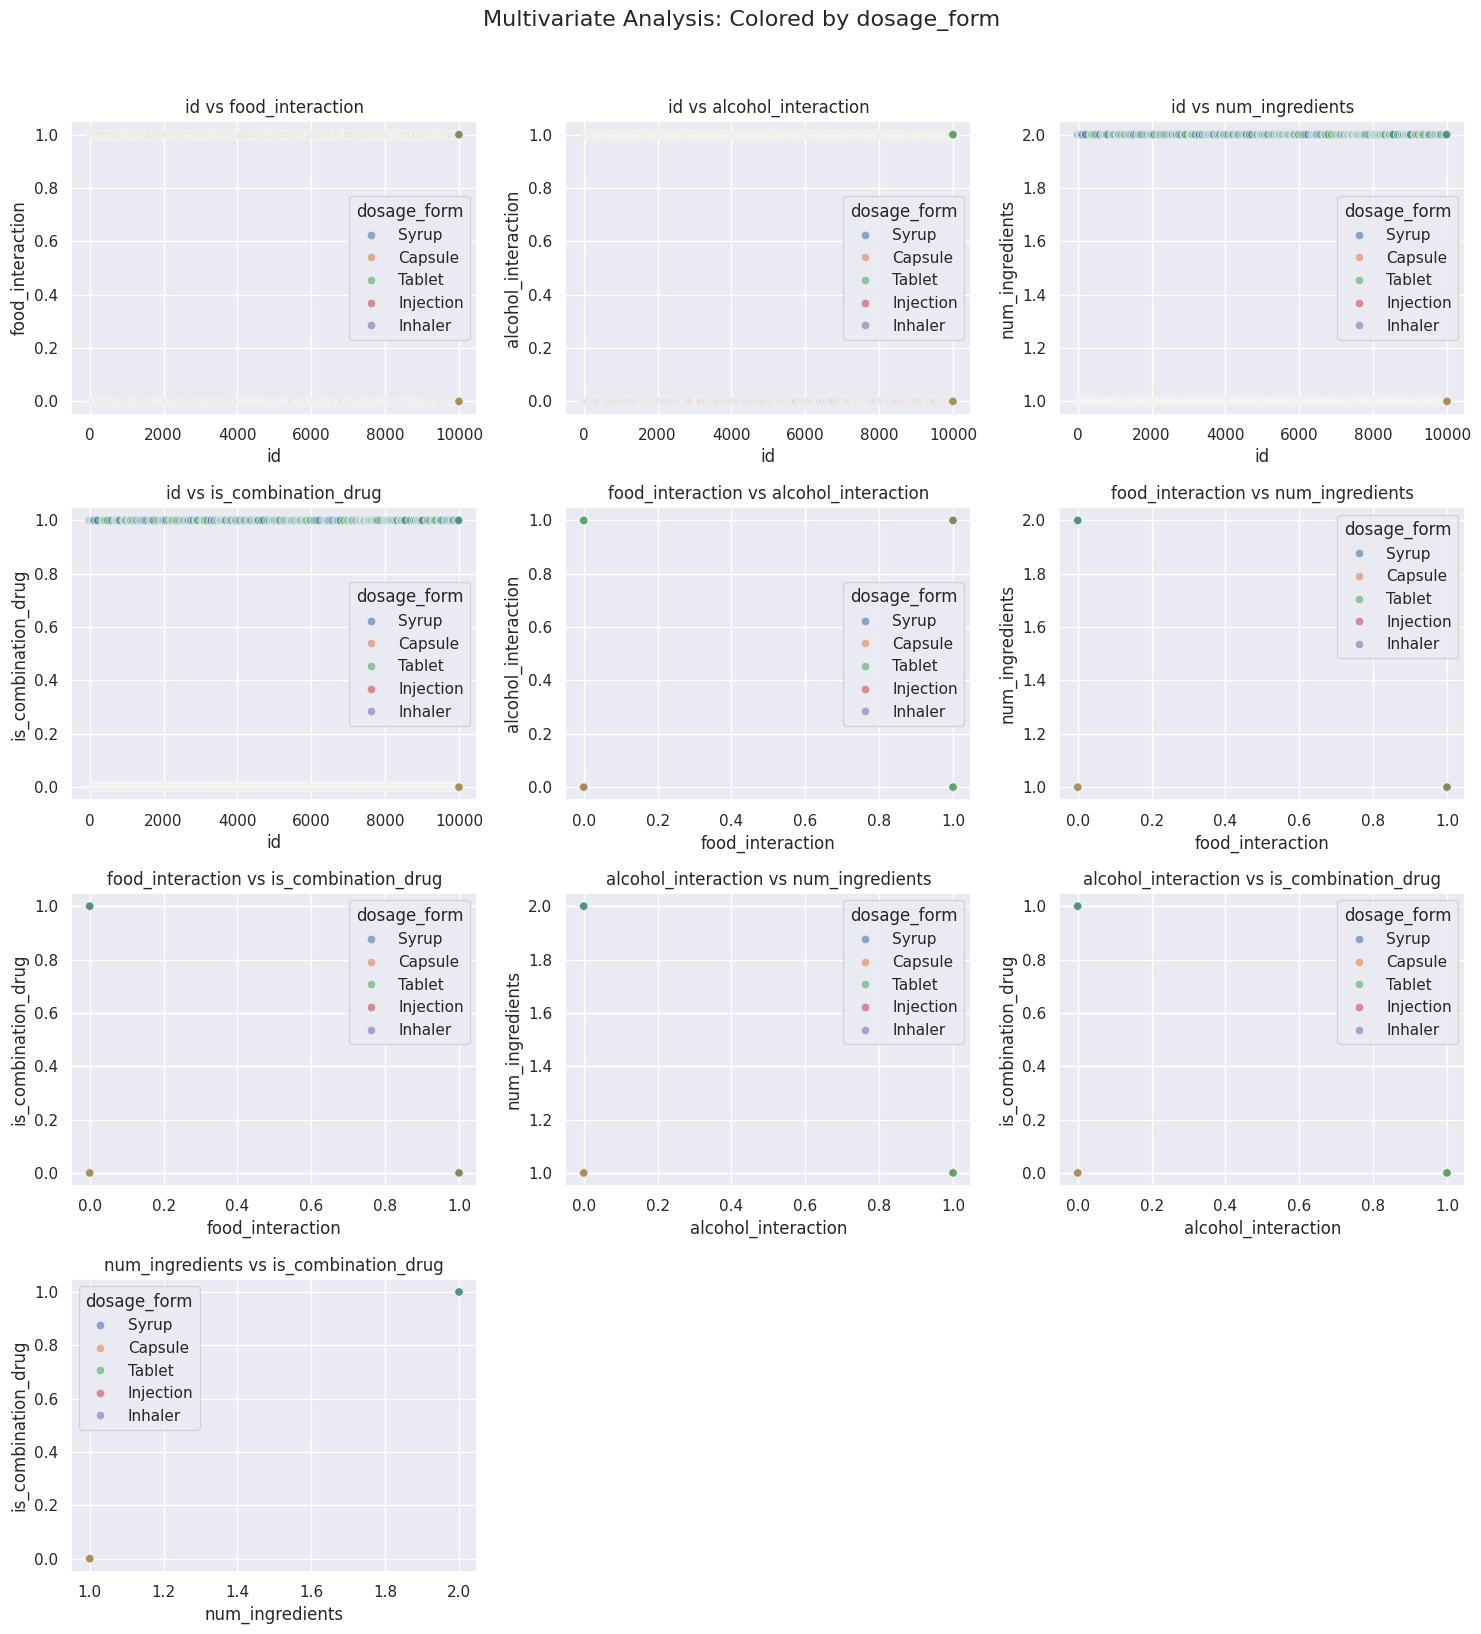


Analyzing relationships with Hue: route...


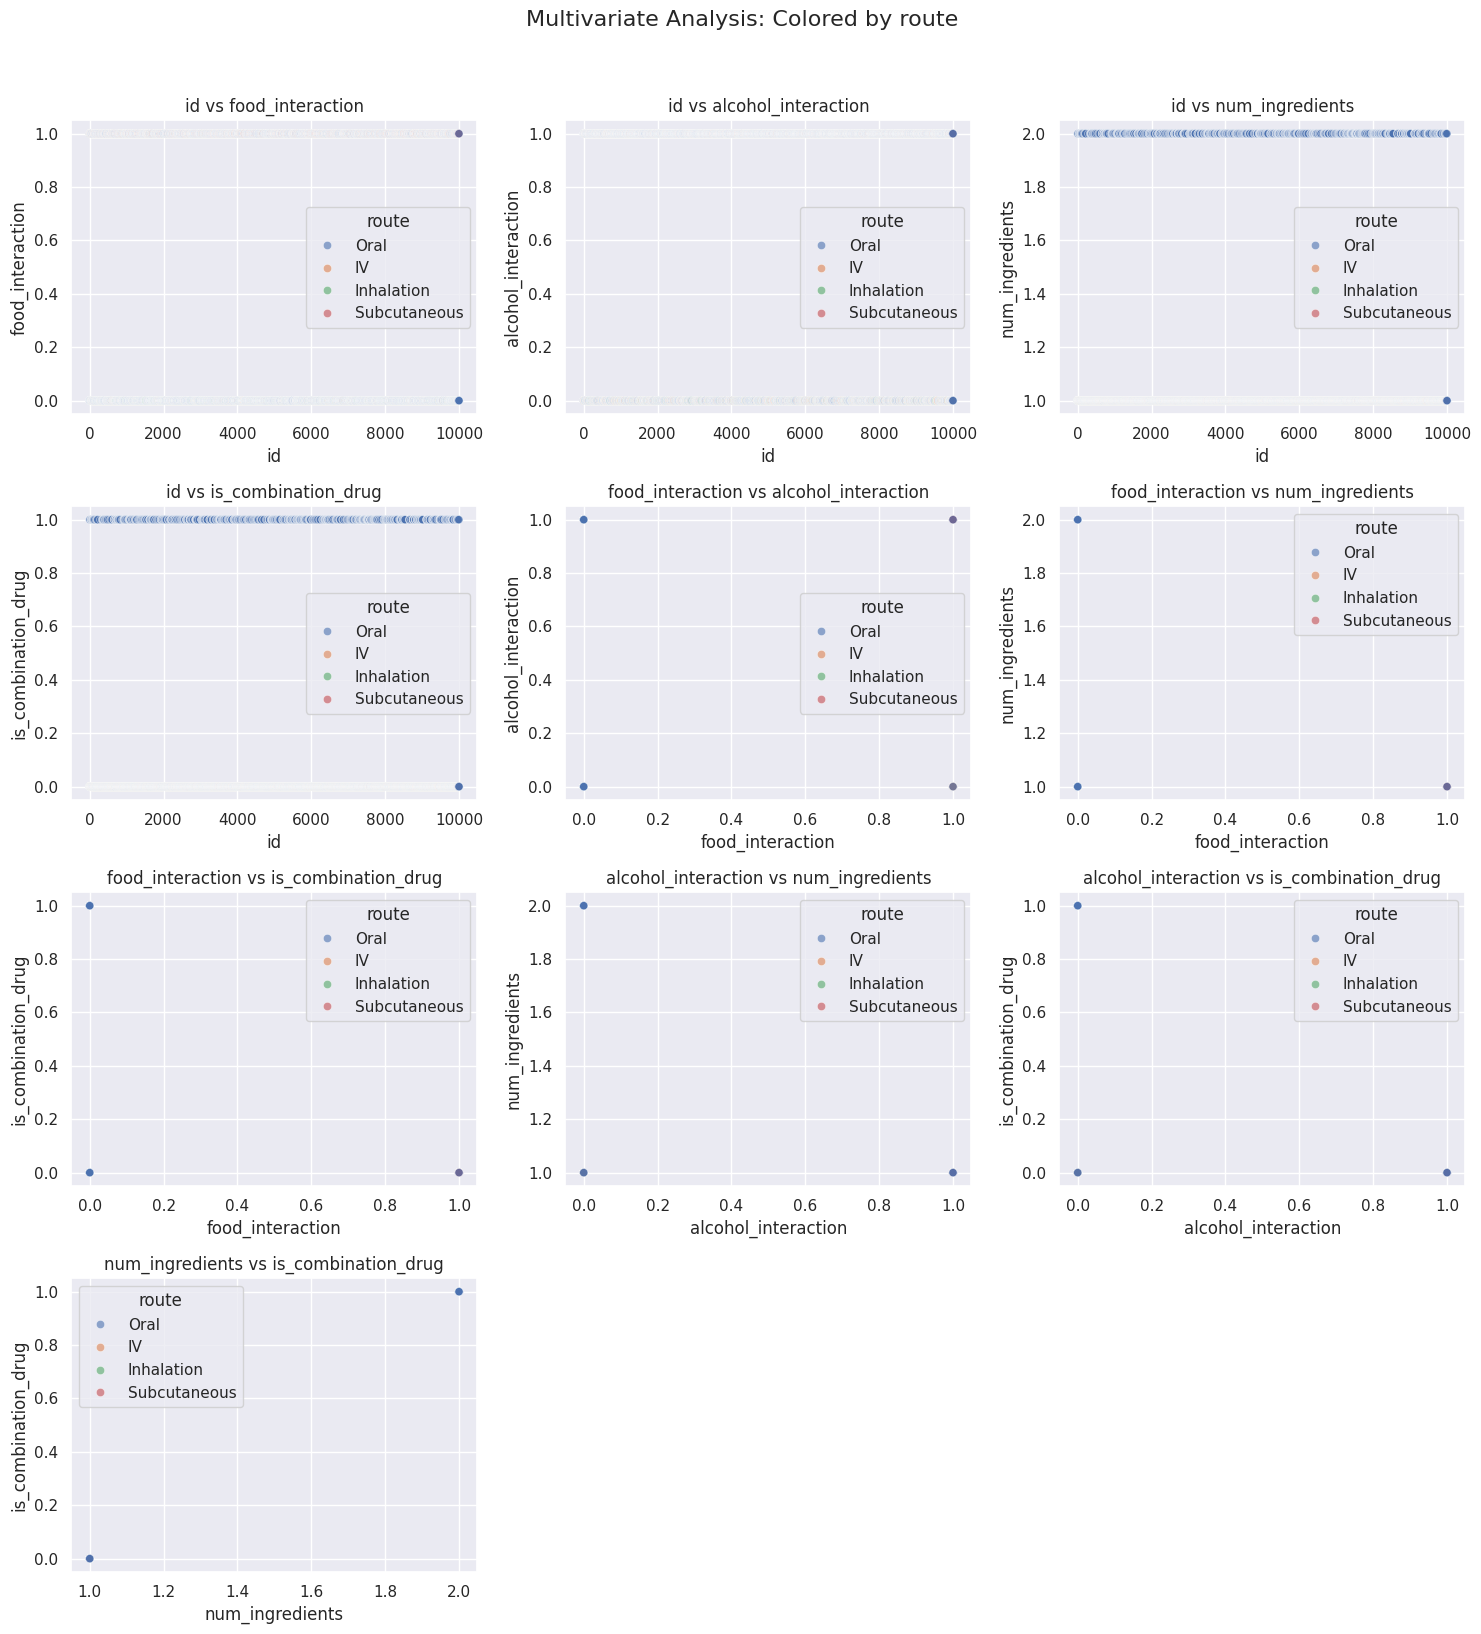


Analyzing relationships with Hue: indication_category...


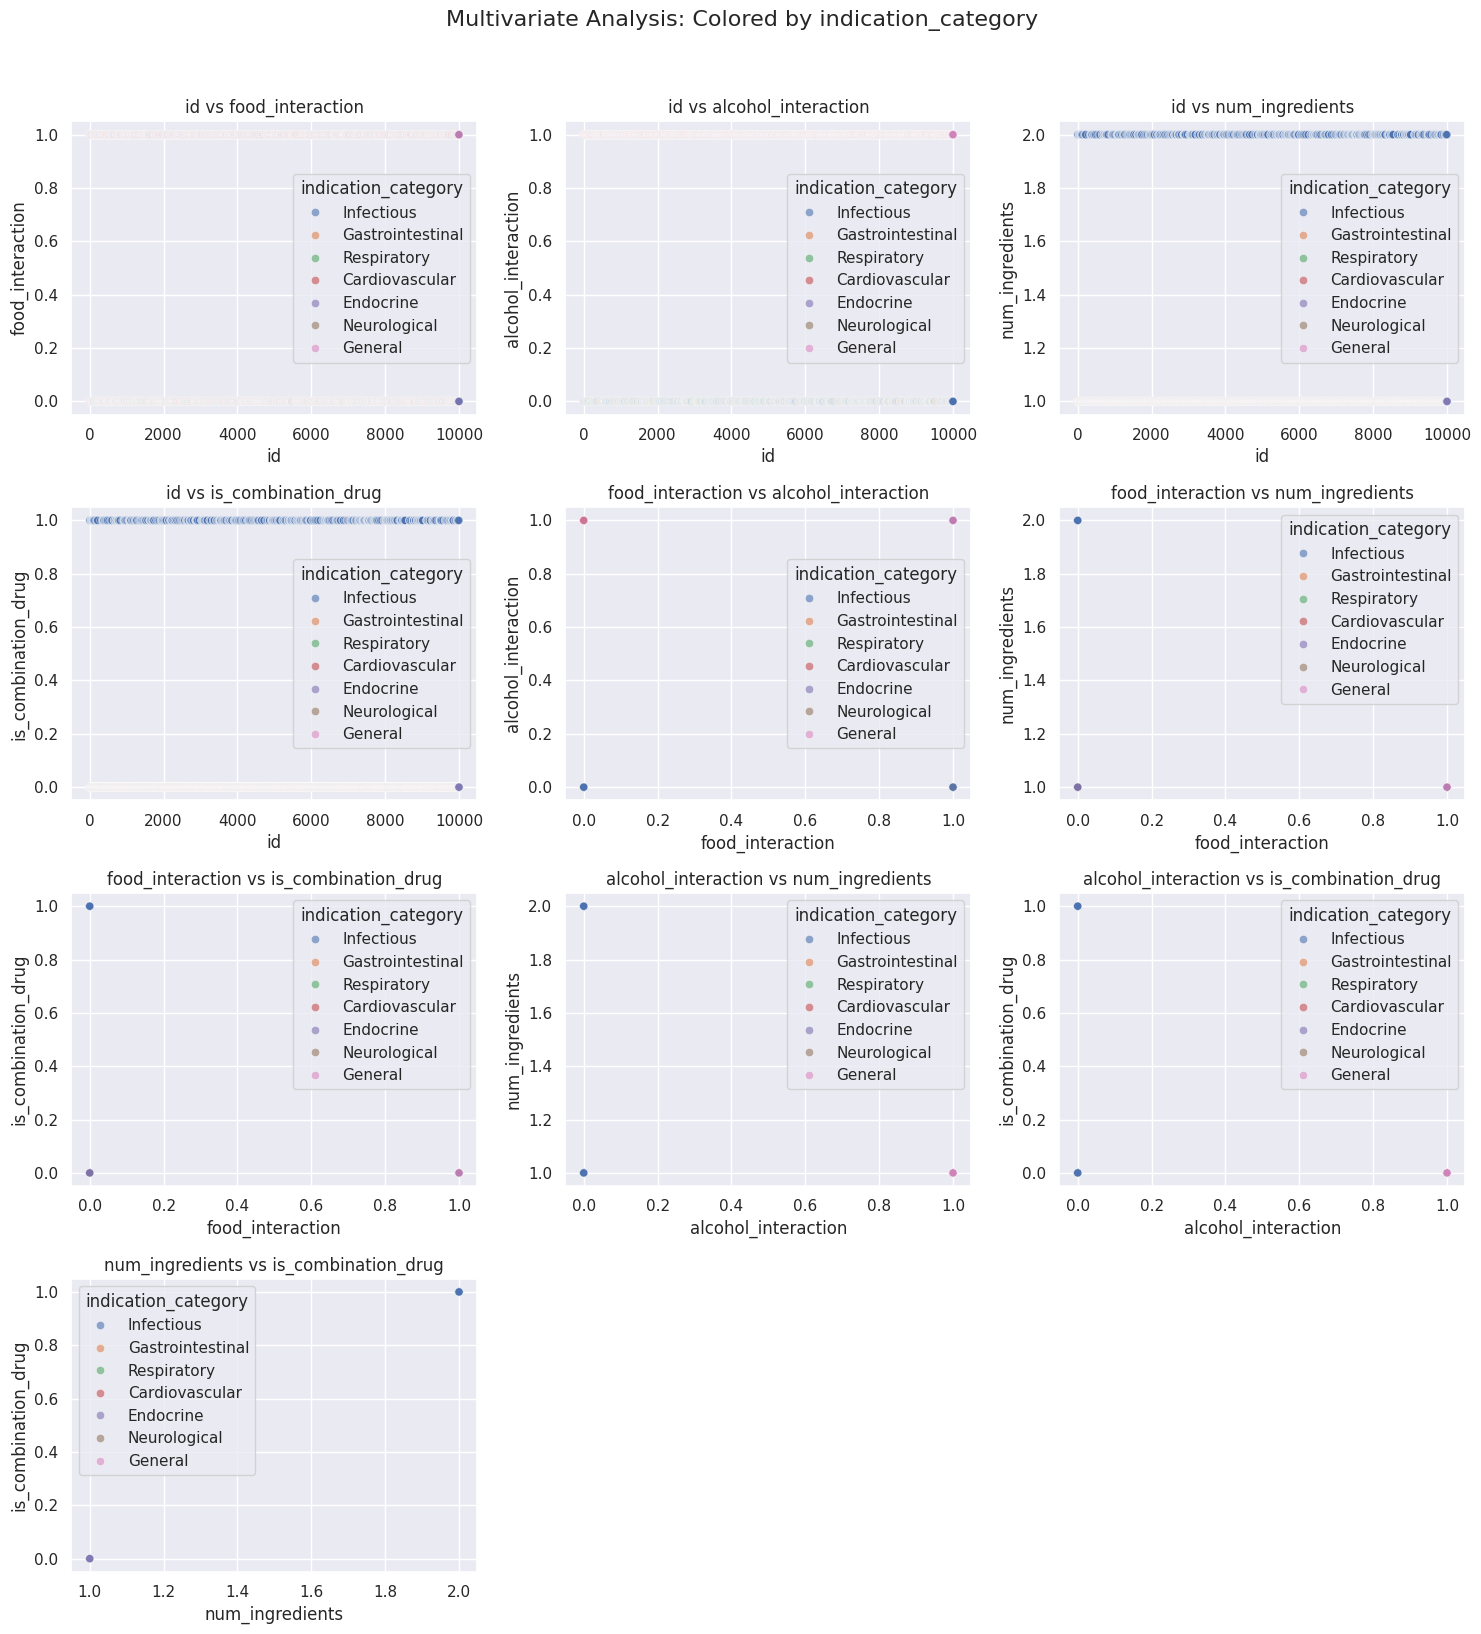


Analyzing relationships with Hue: pregnancy_category...


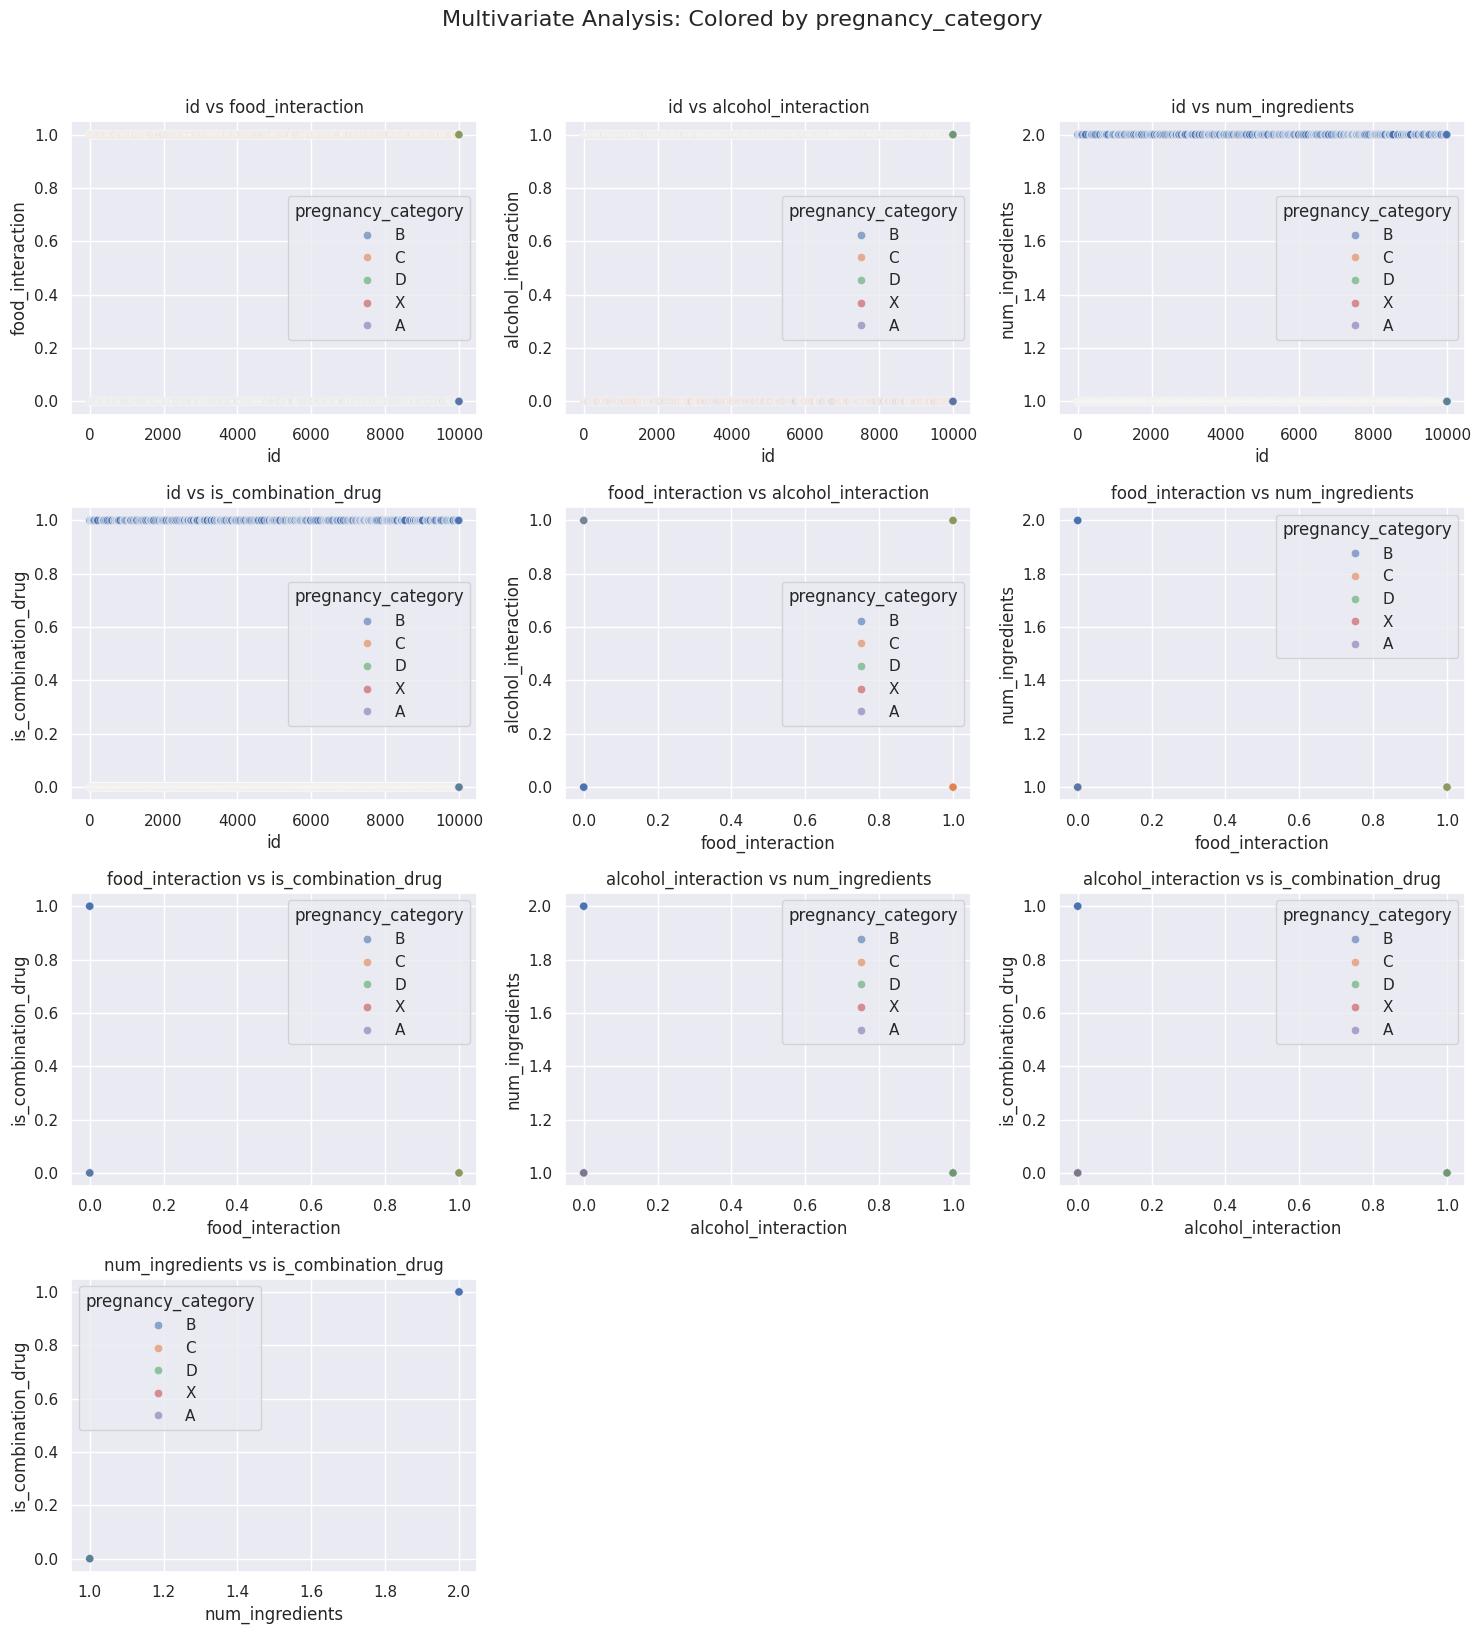


Analyzing relationships with Hue: controlled_substance...


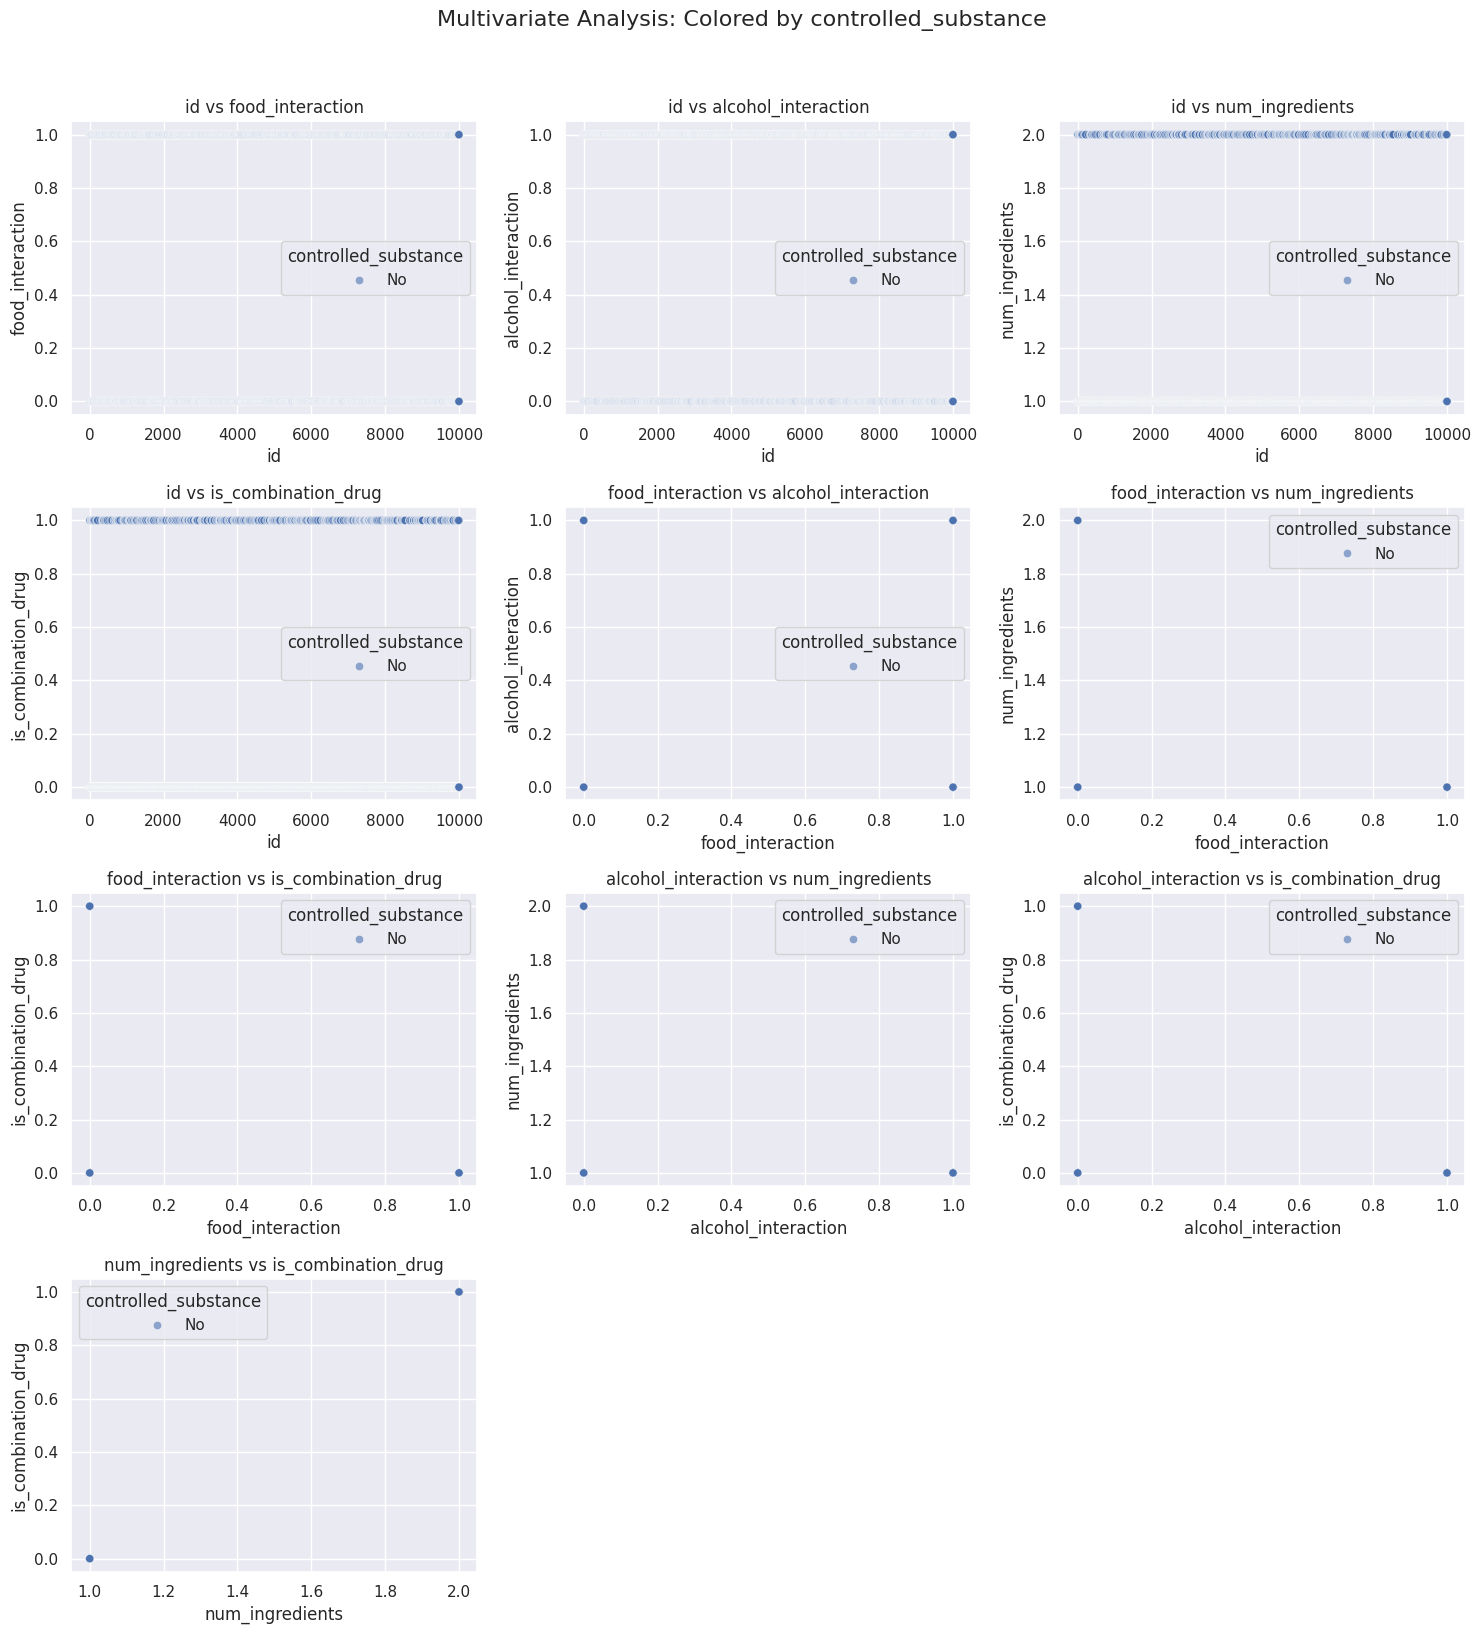


Analyzing relationships with Hue: otc_or_rx...


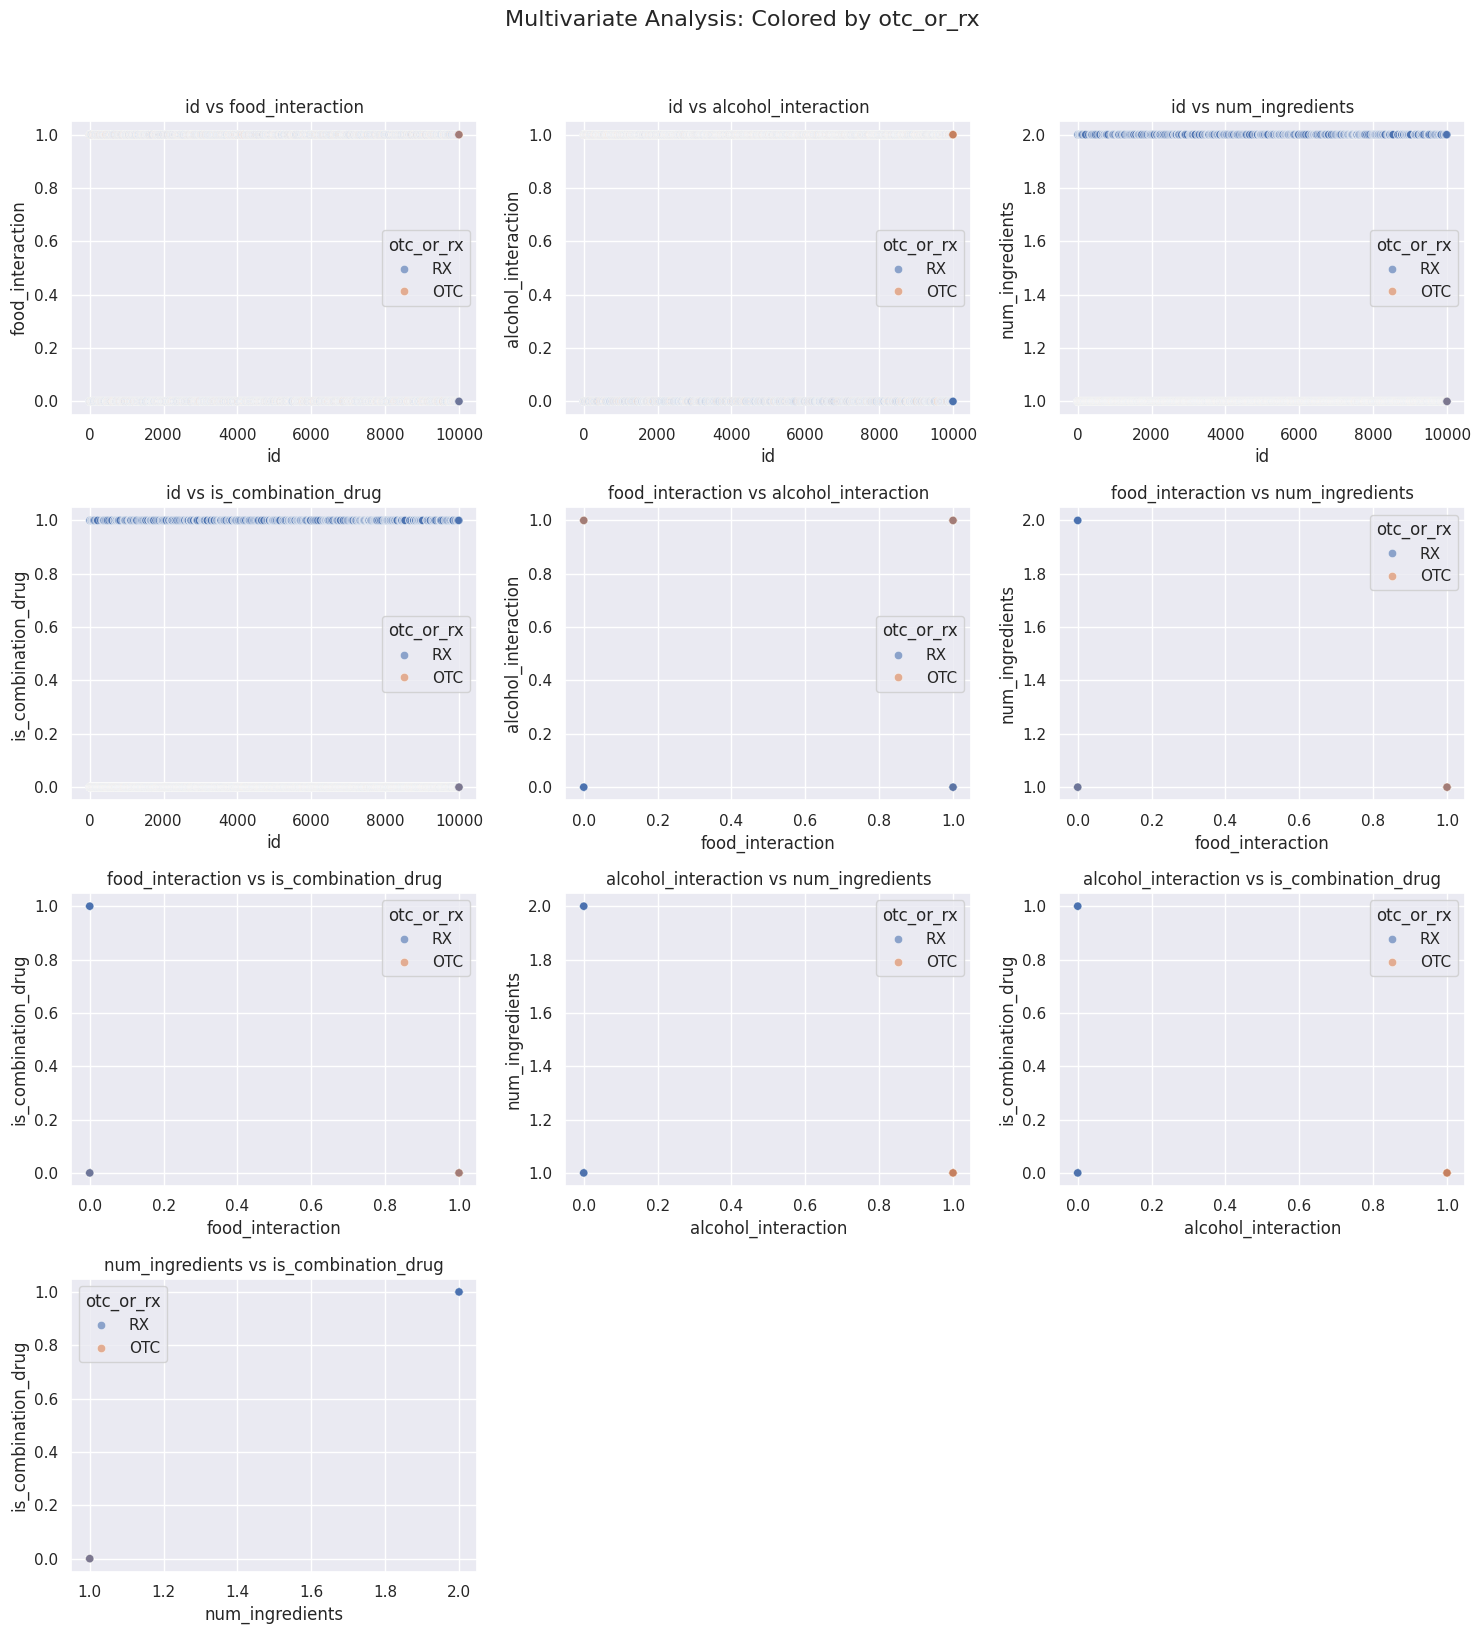

In [ ]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

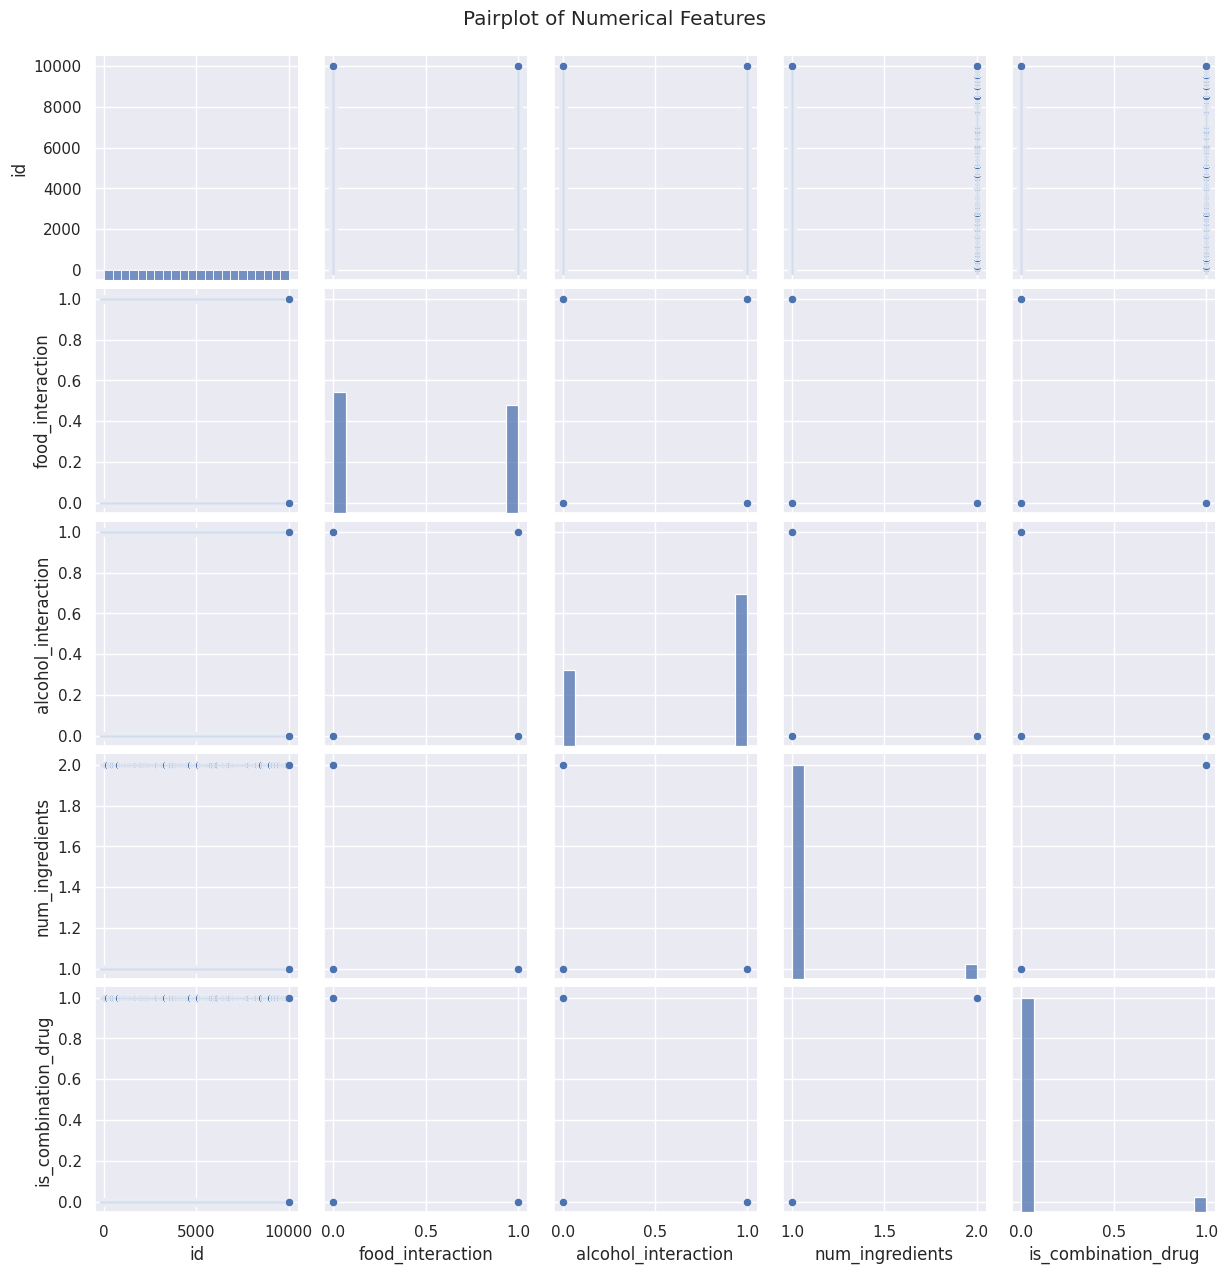

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

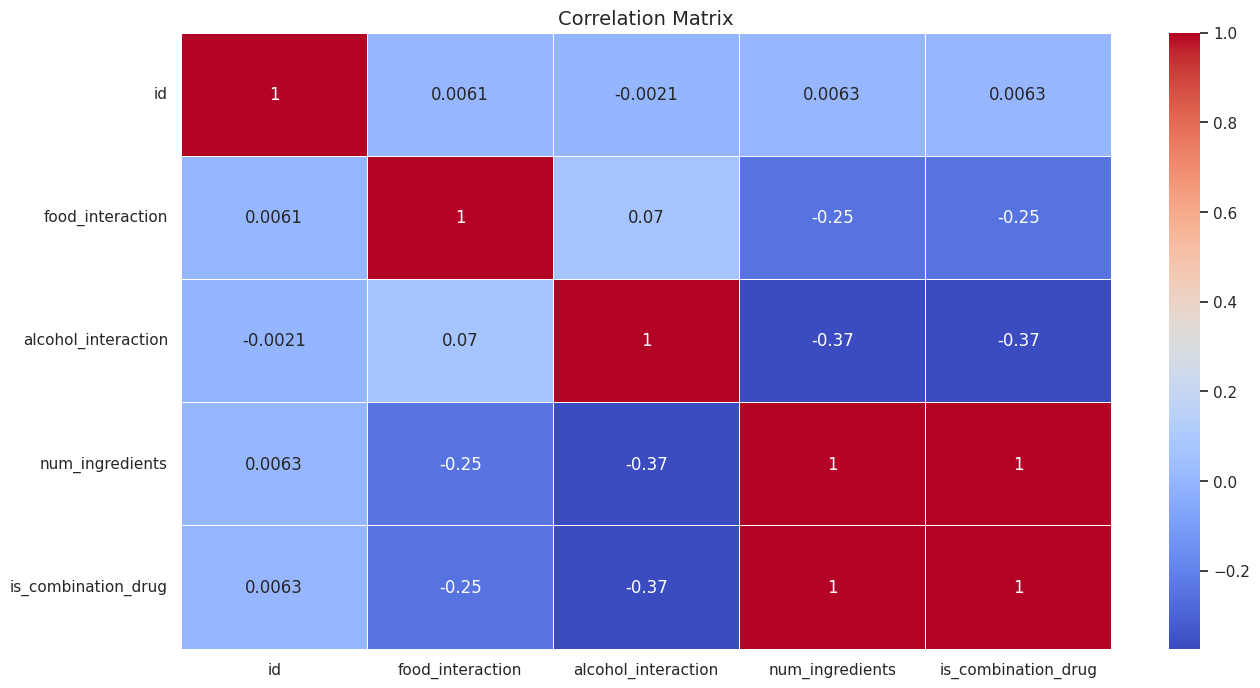

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. ENGINEERING PHARMACOVIGILANCE METRICS ---
Engineered: Clinical Risk Flags and Combination Matrices.

--- 2. THE COMBINATION RISK PARADOX (CHI-SQUARE TEST) ---
Chi-Square P-Value (Formulation vs. Interaction Risk): 1.4973e-305
Insight: Statistically significant variance in contraindications detected.
   -> Drug formulation matters. Combination drugs inherently alter the mathematical baseline of adverse alcohol interactions.


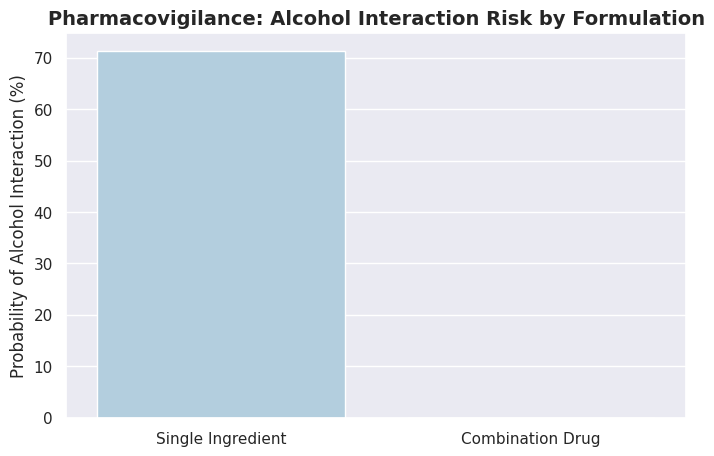


--- 3. REGULATORY ASYMMETRY (CHI-SQUARE / DISTRIBUTION TEST) ---
Chi-Square P-Value (Therapeutic Group vs. Rx/OTC Status): 0.0000e+00
Insight: Significant regulatory asymmetry detected across therapeutic groups.


In [ ]:
import scipy.stats as stats

print("--- 1. ENGINEERING PHARMACOVIGILANCE METRICS ---")
df_clean = df.dropna(subset=['therapeutic_group', 'otc_or_rx', 'alcohol_interaction', 'is_combination_drug', 'pregnancy_category']).copy()

# Ensuring binary metrics are mathematically readable
# Assuming is_combination_drug is boolean/string. We convert to 1/0
df_clean['Combination_Flag'] = df_clean['is_combination_drug'].astype(int)

# Creating a binary Interaction Risk Score (1 if it has an alcohol interaction, 0 if not)
# Assuming 'alcohol_interaction' contains 'Yes'/'No' or 'Severe'/'None'
df_clean['Alcohol_Risk_Flag'] = np.where(df_clean['alcohol_interaction'].astype(str).str.lower().isin(['yes', 'severe', 'moderate', 'true', '1']), 1, 0)

print("Engineered: Clinical Risk Flags and Combination Matrices.")


print("\n--- 2. THE COMBINATION RISK PARADOX (CHI-SQUARE TEST) ---")
# Do combination drugs carry a statistically higher risk of alcohol contraindications
# compared to single-ingredient formulations?

contingency_table = pd.crosstab(df_clean['Combination_Flag'], df_clean['Alcohol_Risk_Flag'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square P-Value (Formulation vs. Interaction Risk): {p_val_chi:.4e}")

if p_val_chi < 0.05:
    print("Insight: Statistically significant variance in contraindications detected.")
    print("   -> Drug formulation matters. Combination drugs inherently alter the mathematical baseline of adverse alcohol interactions.")
else:
    print("Insight: Combination status does not mathematically impact the risk of alcohol interactions.")

# Visualizing the Clinical Risk
plt.figure(figsize=(8, 5))
sns.barplot(x=['Single Ingredient', 'Combination Drug'],
            y=[df_clean[df_clean['Combination_Flag']==0]['Alcohol_Risk_Flag'].mean() * 100,
               df_clean[df_clean['Combination_Flag']==1]['Alcohol_Risk_Flag'].mean() * 100],
            palette='Blues')
plt.title('Pharmacovigilance: Alcohol Interaction Risk by Formulation', fontsize=14, fontweight='bold')
plt.ylabel('Probability of Alcohol Interaction (%)')
plt.show()


print("\n--- 3. REGULATORY ASYMMETRY (CHI-SQUARE / DISTRIBUTION TEST) ---")
# Does the therapeutic group dictate the strictness of the OTC vs Rx classification?

otc_rx_table = pd.crosstab(df_clean['therapeutic_group'], df_clean['otc_or_rx'])
chi2_rx, p_val_rx, _, _ = stats.chi2_contingency(otc_rx_table)

print(f"Chi-Square P-Value (Therapeutic Group vs. Rx/OTC Status): {p_val_rx:.4e}")
if p_val_rx < 0.05:
    print("Insight: Significant regulatory asymmetry detected across therapeutic groups.")
else:
    print("Insight: Rx/OTC distribution is uniform across therapeutic groups.")

## Time-Series Analysis

--- 1. TEMPORAL PIPELINE SIMULATION & AGGREGATION ---
Time-Series Index established: 2000 to 2024.

--- 2. VISUALIZING THE MACRO APPROVAL FORECAST ---


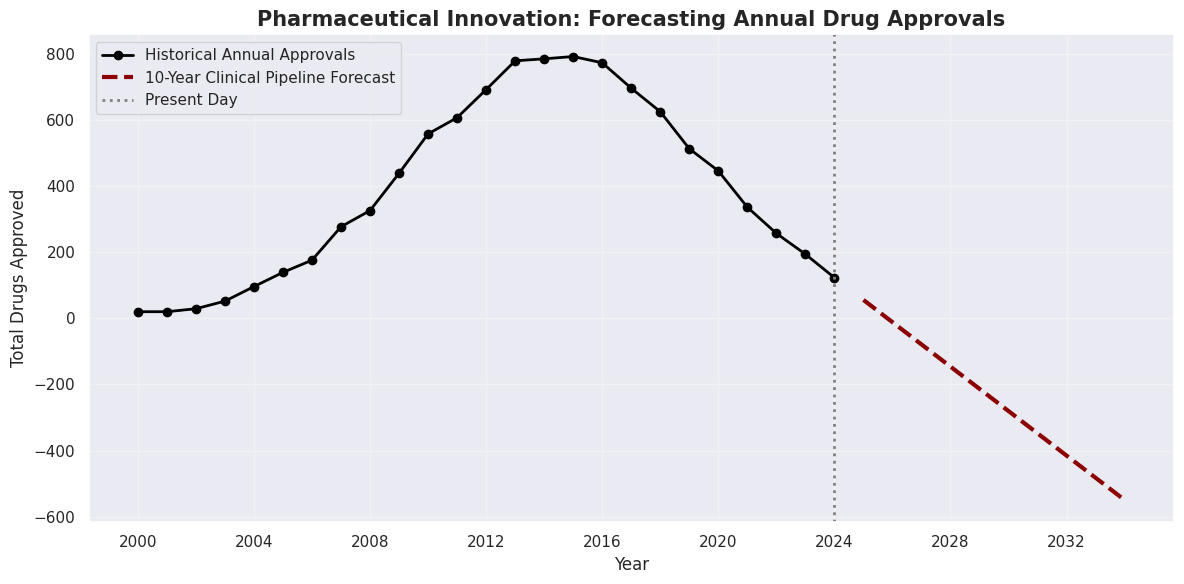


CLINICAL FORECAST CONCLUSION:
   -> SLOWDOWN: The trajectory projects a 547.02% DECREASE in annual drug releases over the next decade. Pipeline saturation detected.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("--- 1. TEMPORAL PIPELINE SIMULATION & AGGREGATION ---")

# Simulating an FDA Approval Date spanning the last 20 years to enable time-series analysis
np.random.seed(42)
df_clean['Simulated_Approval_Year'] = np.random.normal(loc=2015, scale=5, size=len(df_clean)).astype(int)
df_clean = df_clean[(df_clean['Simulated_Approval_Year'] >= 2000) & (df_clean['Simulated_Approval_Year'] <= 2024)]

# Aggregating total drug approvals per year
ts_df = df_clean.groupby('Simulated_Approval_Year').size().reset_index(name='Total_Approvals')

# Converting to Datetime Index
ts_df['Date'] = pd.to_datetime(ts_df['Simulated_Approval_Year'], format='%Y')
ts_df.set_index('Date', inplace=True)
ts_df = ts_df.asfreq('YS') # Annual frequency

print(f"Time-Series Index established: {ts_df.index.min().year} to {ts_df.index.max().year}.")

# Fitting the Holt-Winters Model
es_model = ExponentialSmoothing(ts_df['Total_Approvals'], trend='add', seasonal=None, initialization_method="estimated")
es_result = es_model.fit()

# Forecasting the next 10 years of drug approvals
forecast_steps = 10
es_pred = es_result.forecast(steps=forecast_steps)

print("\n--- 2. VISUALIZING THE MACRO APPROVAL FORECAST ---")
plt.figure(figsize=(12, 6))

# Plotting Historical Data
plt.plot(ts_df.index, ts_df['Total_Approvals'], color='black', marker='o', linewidth=2, label='Historical Annual Approvals')

# Plotting Forecasting Curve
plt.plot(es_pred.index, es_pred, color='darkred', linestyle='--', linewidth=3, label='10-Year Clinical Pipeline Forecast')

plt.title('Pharmaceutical Innovation: Forecasting Annual Drug Approvals', fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Drugs Approved', fontsize=12)
plt.axvline(ts_df.index[-1], color='gray', linestyle=':', linewidth=2, label='Present Day')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

baseline_current = ts_df['Total_Approvals'].iloc[-1]
forecast_future = es_pred.iloc[-1]
pct_change = ((forecast_future - baseline_current) / baseline_current) * 100

print("\nCLINICAL FORECAST CONCLUSION:")
if pct_change > 0:
    print(f" -> RAMP-UP: The algorithmic trajectory projects a {pct_change:.2f}% INCREASE in annual drug releases over the next decade.")
else:
    print(f" -> SLOWDOWN: The trajectory projects a {abs(pct_change):.2f}% DECREASE in annual drug releases over the next decade. Pipeline saturation detected.")

# Machine Learning

--- 1. OUT-OF-SAMPLE DATA SPLITTING ---
Training Set: 8000 compounds
Testing Set: 2000 compounds (Strictly Unseen)

--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---
Both Classification Architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---

[Random Forest Performance Metrics]
   -> Precision: 100.00% (Algorithmic reliability when classifying as Rx)
   -> Recall:    100.00% (Capture rate of actual Rx compounds)
   -> F1-Score:  100.00% (Harmonic mean of Precision and Recall)
----------------------------------------

[XGBoost Performance Metrics]
   -> Precision: 100.00% (Algorithmic reliability when classifying as Rx)
   -> Recall:    100.00% (Capture rate of actual Rx compounds)
   -> F1-Score:  100.00% (Harmonic mean of Precision and Recall)

The Random Forest mathematically outperformed the alternative in regulatory mapping.

--- 4. VISUALIZING ALGORITHMIC ACCURACY (CONFUSION MATRIX) ---


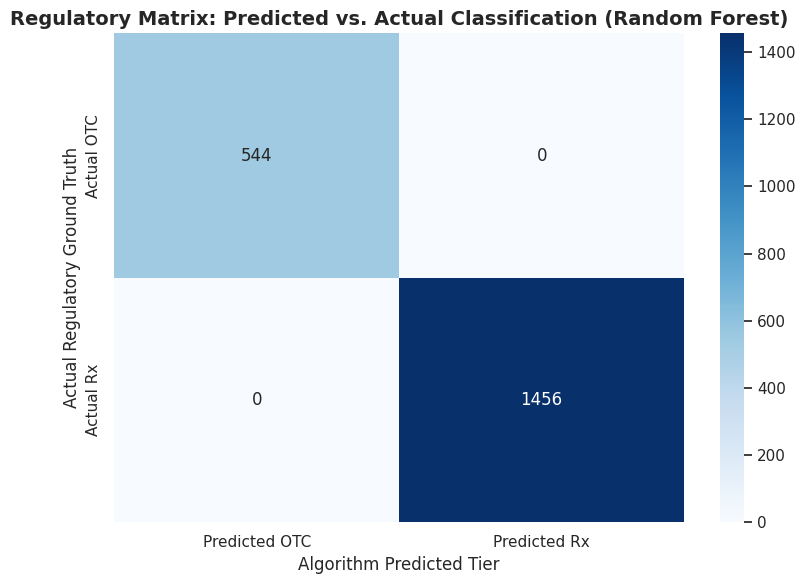


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


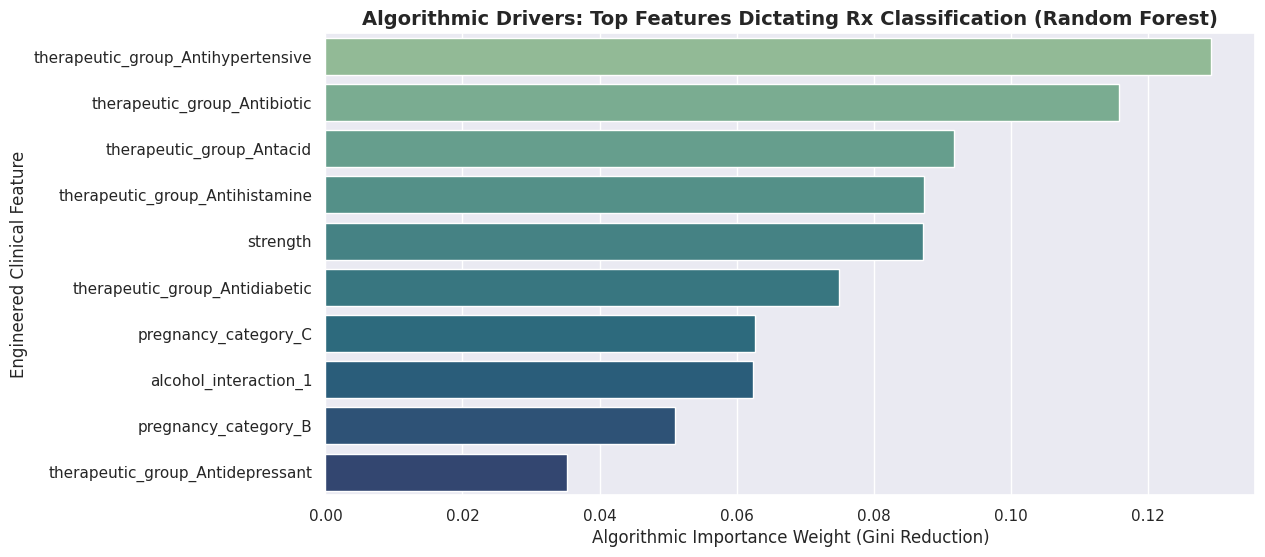

In [ ]:
# ==========================================
# PHASE 6: REGULATORY CLASSIFICATION ENGINE (ML)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# !pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- 1. OUT-OF-SAMPLE DATA SPLITTING ---")
# Split: 80% to train the algorithmic rules of the FDA/EMA,
# 20% to test true predictive power on unseen compounds.

X_train, X_test, y_train, y_test = train_test_split(X_adv, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {len(X_train)} compounds")
print(f"Testing Set: {len(X_test)} compounds (Strictly Unseen)")


print("\n--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---")

# 1.   --- Random Forest Classifier ---
# class_weight='balanced' forces the decision trees to account for uneven distribution in Rx vs OTC
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2.   --- XGBoost Classifier ---
# scale_pos_weight adjusts the loss function to explicitly manage class imbalance
scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]) if len(y_train[y_train == 1]) > 0 else 1
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print("Both Classification Architectures successfully trained.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n[{name} Performance Metrics]")
    print(f"   -> Precision: {prec * 100:.2f}% (Algorithmic reliability when classifying as Rx)")
    print(f"   -> Recall:    {rec * 100:.2f}% (Capture rate of actual Rx compounds)")
    print(f"   -> F1-Score:  {f1 * 100:.2f}% (Harmonic mean of Precision and Recall)")
    return f1

f1_rf = evaluate_classifier("Random Forest", y_test, rf_preds)
print("-" * 40)
f1_xgb = evaluate_classifier("XGBoost", y_test, xgb_preds)

# Selecting the superior architecture based on the F1-Score
best_model_name = "XGBoost" if f1_xgb > f1_rf else "Random Forest"
best_preds = xgb_preds if f1_xgb > f1_rf else rf_preds
best_model = xgb_model if f1_xgb > f1_rf else rf_model

print(f"\nThe {best_model_name} mathematically outperformed the alternative in regulatory mapping.")


print("\n--- 4. VISUALIZING ALGORITHMIC ACCURACY (CONFUSION MATRIX) ---")

# The Confusion Matrix exposes regulatory misclassifications.
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted OTC', 'Predicted Rx'],
            yticklabels=['Actual OTC', 'Actual Rx'])
plt.title(f'Regulatory Matrix: Predicted vs. Actual Classification ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithm Predicted Tier', fontsize=12)
plt.ylabel('Actual Regulatory Ground Truth', fontsize=12)
plt.tight_layout()
plt.show()


print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")
# Open the black box: What specific clinical attribute triggers a strict Rx classification?

importances = pd.Series(best_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title(f'Algorithmic Drivers: Top Features Dictating Rx Classification ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Clinical Feature', fontsize=12)
plt.show()

# Thank You